In [1]:
from lcpy.calculators.helpers import ExchangeHolder, ImpactCalculator, ImpactHandler
from lcpy.calculators.bw_int import mpLCAer
import os
from lcpy.hvs.hvs import create_dataframe_dict, save_dataframes_to_excel, create_name_dictionaries,plot_stacked_percentage_bar_grid, plot_stacked_percentage_bar_sub_processes, plot_stacked_percentage_barchart_seaborn
from lcpy.hvs.map_dicts import create_mapping, create_list_with_unique_activities
from lcpy.hvs.hvs import make_characterized_inventory_dfs_simple_lca
from lcpy.calculators.env_calc import fast_calculator

# General configuration parameters

In [2]:
target_dir = "path_of_directory_where_to_store_results"
os.makedirs(target_dir, exist_ok=True)

In [3]:
methods_list = [
('TRACI v2.1', 'acidification', 'acidification potential (AP)'),
('TRACI v2.1', 'climate change', 'global warming potential (GWP100)'),
('TRACI v2.1', 'ecotoxicity: freshwater', 'ecotoxicity: freshwater'),
('TRACI v2.1', 'eutrophication', 'eutrophication potential'),
('TRACI v2.1', 'human toxicity: carcinogenic', 'human toxicity: carcinogenic'),
('TRACI v2.1', 'human toxicity: non-carcinogenic', 'human toxicity: non-carcinogenic'),
('TRACI v2.1', 'ozone depletion', 'ozone depletion potential (ODP)'),
('TRACI v2.1', 'particulate matter formation', 'particulate matter formation potential (PMFP)'),
('TRACI v2.1', 'photochemical oxidant formation', 'maximum incremental reactivity (MIR)'),
]

method_units_list = ['kg SO2-Eq',
 'kg CO2-Eq',
 'CTUe',
 'kg N-Eq',
 'CTUh',
 'CTUh',
 'kg CFC-11-Eq',
 'kg PM2.5-Eq',
 'kg O3-Eq',
]

In [4]:
brightway_configuration_dictionary = {
    "path_to_brightway_project": "path_to_folder_containing_the_bw_environment_and_packages_installed_there",
    "bw_project": "bw_project_name",
    "bw_database": "bw_project_database_name",
    "bw_biosphere": "bw_project_biosphere_database_name",
    "bw_ecoinvent": "ecoinvent_database_used_name"
}

In [5]:
methods_gp = methods_list[:]
impact_categories_names = ['AP', 'GWP100', 'ECFW', 'EP', 'HTC', 'HTNC', 'ODP', 'PMFP', 'MIR']

In [6]:
impact_categories_units = method_units_list
scenario_names = ['one']

In [7]:
timeframe = 2 #operational lifetime after construction
time_step = 1
construction_years = 0

# Simple parametric model

In [8]:
BWR_capacity = 1500
PWR_capacity = 800
NG_ccpp_capacity = 400
NG_convpp_capacity = 750
NG_cogen_conv_capacity = 900
NG_cogen_cc_capacity = 1100
Hydro_pumped_capacity = 420
DGE_capacity = 85
Wind_1_3_capacity = 980

In [9]:
nuclear_capacity = BWR_capacity + PWR_capacity
ng_capacity = NG_ccpp_capacity + NG_convpp_capacity + NG_cogen_conv_capacity + NG_cogen_cc_capacity
res_capacity = Hydro_pumped_capacity + DGE_capacity + Wind_1_3_capacity

In [10]:
total_capacity = nuclear_capacity + ng_capacity + res_capacity

In [11]:
# keys_infrastructure = {
#     'Building' : '1c86b20364aaf5005008b6294c8603ee_copy1'
# }
# infrastructure_exchanges_amounts = [1.]

# Example:
We consider three sub_processes: Nuclear power generation, RES power generation, and fossil power generation (only natural gas)

We navigate in the activity browser or brightway in the project defined in the brightway_configuration_dictionary above, and we derive the
keys that point to activities representing nuclear power generation from boiling or pressure water reactors, natural gas power generation from conventional or combined
cycle plants for standalone and co-generation plants, hydro power generation from pumped storage, deep geothermal power generation, onshore wind power generation.
We consider the UK as our geographical reference.

We are using ecoinvent processes `as is'. Nevertheless, one could create their own processes and assign their own keys to them.

In [12]:
keys_nuclear_power_generation = {
'PWR' :  'bw_key_pointing_to_relevant_process',
'BWR' : 'bw_key_pointing_to_relevant_process'
}
nuclear_exchanges_amounts = [
PWR_capacity/nuclear_capacity,
BWR_capacity/nuclear_capacity
]

keys_fossil_power_generation = {
'NG_ccpp' :  'bw_key_pointing_to_relevant_process',
'NG_convpp' : 'bw_key_pointing_to_relevant_process',
'NG_cogen_conv' :  'bw_key_pointing_to_relevant_process',
'NG_cogen_cc' : 'bw_key_pointing_to_relevant_process',
}
fossil_exchanges_amounts = [
NG_ccpp_capacity/ng_capacity,
NG_convpp_capacity/ng_capacity,
NG_cogen_conv_capacity/ng_capacity,
NG_cogen_cc_capacity/ng_capacity,
]

keys_res_power_generation = {
'Hydro' :  'bw_key_pointing_to_relevant_process',
'DGE' : 'bw_key_pointing_to_relevant_process',
'Wind' :  'bw_key_pointing_to_relevant_process',
}
res_exchanges_amounts = [
Hydro_pumped_capacity/res_capacity,
DGE_capacity/res_capacity,
Wind_1_3_capacity/res_capacity,
]

In [13]:
print(nuclear_exchanges_amounts)
print(nuclear_exchanges_amounts[0] + nuclear_exchanges_amounts[1])

[0.34782608695652173, 0.6521739130434783]
1.0


And here we set the dictionaries for the main process

In [14]:
keys_total_power_generation = {
'Nuclear': '',
'Fossil' : '',
'RES' : '',
}

mp_exchanges_amounts = [
nuclear_capacity/total_capacity,
ng_capacity/total_capacity,
res_capacity/total_capacity,
]

To perform the analysis the dictionaries with keys and the lists with the exchange amounts for eahc sub-process need to be buckled up in lists

In [15]:
key_list_sub_processes = [keys_nuclear_power_generation, keys_fossil_power_generation, keys_res_power_generation]
exchanges_list_sub_processes = [nuclear_exchanges_amounts, fossil_exchanges_amounts, res_exchanges_amounts]

Creates a dictionary with keys the keys of the first dictionary and values of the dictionaries included in the second list

In [16]:
mapping_names = create_mapping(keys_total_power_generation, key_list_sub_processes)

Creates a list with the names of each sub-sub-processes considered

In [17]:
unique_activities = create_list_with_unique_activities(key_list_sub_processes)

In [18]:
mapping_exchanges = create_mapping(keys_total_power_generation, exchanges_list_sub_processes)

Creates an instance that can run brightway. It uses 4 cpus, it considers the impact assessment methods provided, and runs everything in the bw project specified in the bw_config_dictionary. Then this bw environment needs to be set up.

Create the respective mapping dictionaries for the main process.

In [19]:
main_process_names = ['Electricity production']

In [20]:
mapping_exchanges_mp = {main_process_names[0]: mp_exchanges_amounts}

In [21]:
names_dictionary = create_name_dictionaries(mapping_names, key_list_sub_processes)

In [22]:
names_dictionary_graphite_main = {main_process_names[0]: list(names_dictionary.keys()) }

In [23]:
my_lca = mpLCAer(4, methods_gp, brightway_configuration_dictionary)

In [24]:
my_lca.import_isolated_environment()

ValueError: Invalid Brightway venv path: path_to_folder_containing_the_bw_environment_and_packages_installed_there

Calculates the unit impact, inventories, and characterized inventories, for each sub-sub-process in each sub-process.
The impact, inventory, and characterized inventory values are stored in dictionaries of the my_lca object.

In [25]:
my_lca.lca_calculations(mapping_names)

RuntimeError: Brightway environment not initialized. Call `initialize_bw_environment()` first.

This notebook is mainly concerned with calculating and presenting the LCA results in terms of impact categories. To calculate the inventory and the impact caused by each inventory flow, the below lines of code can be run which are better explained in the fully-dynamic LCA example and the technical documentation. To perfrom this analysis per environmental flow a fast_calculator instance need to be loaded (again better explained in the next examples (MC/GSA/semi-dynamic/fully-dynamic).

The next nine cells can be omitted if only the actual impacts are to be explored without being concerned about the environmental flows.

In [25]:
my_lca.derive_technosphere_and_biosphere_dictionaries(mapping_names, "Main process")

All biosphere dictionaries are the same
All technosphere dictionaries are the same


In [26]:
my_calculator = fast_calculator()

In [27]:
my_calculator.sum_inventory_per_sub_sub_process(my_lca.unit_inventory)

In [28]:
my_calculator.sum_characterized_inventory_per_sub_sub_process(my_lca.unit_char_inventory)

In [29]:
my_calculator.emissions_calculation_simple_lca(mapping_exchanges, my_calculator.summed_unit_inventories)

In [30]:
my_calculator.characterized_inventory_calculation_simple_lca(mapping_exchanges, my_calculator.summed_unit_characterized_inventories)

In [31]:
my_calculator.emissions_calculation_total_simple_lca(mp_exchanges_amounts, my_calculator.inventory, "Main process" )

In [32]:
my_calculator.characterized_inventory_calculation_total_simple_lca(mp_exchanges_amounts, my_calculator.characterized_inventory, "Main process")

In [33]:
dictionary_with_dfs_per_environmental_flow_mp = make_characterized_inventory_dfs_simple_lca(my_calculator.total_char_inventory['Main process'], impact_categories_names, my_lca.biosphere_dict['Main process'], 0)

In [34]:
dictionary_with_dfs_per_environmental_flow_elec_cons = make_characterized_inventory_dfs_simple_lca(my_calculator.characterized_inventory['RES'],impact_categories_names, my_lca.biosphere_dict['Main process'], 0)

Here the parenthesis that explores the inventory flows ends and the analysis for the impact categories continues.

Creates instances to handle the exchange and impacts for the sub-processes

In [35]:
sp_exchange_manager = ExchangeHolder(methods_gp)
sp_impact_calculator = ImpactCalculator()

Creates dictionary mapping the sub-processes to the amount of exchange of each included sub-sub-process

In [36]:
sp_exchange_manager.create_exchange_arrays(mapping_exchanges)

Scales, for each sub-process, the unit impact of each sub-sub-process with each exchange amount --> Calculate unit impact of each sub-process

In [37]:
sp_impact_calculator.impact_calculation_simple(my_lca.unit_impacts, sp_exchange_manager.exchanges_dict)

Creates a handler instance

In [38]:
sp_results_handler = ImpactHandler(impact_categories_names)

Creates dataframes handling the impact results for each sub-process (for the unit impact of each sub-process). They are held in a dictionary of the sp_results_handler

In [39]:
sp_results_handler.create_dataframes(sp_impact_calculator.simple_impacts, names_dictionary)

We need now to scale the unit results for the sub-processes with the exchange amounts for the main process.
We create an impact handler and a list holding the name of the main process

In [40]:
mp_results_handler = ImpactHandler(impact_categories_names)

Summarizes the unit impact of each sub-process included in the main process in a dictionary of the handler

In [41]:
mp_results_handler.calculate_total_unit_impact(sp_results_handler.total_impact_arrays, main_process_names[0])

Creates instances to handle the exchange and impacts for the sub-processes

In [42]:
mp_exchange_manager = ExchangeHolder(methods_gp)
mp_impact_calculator = ImpactCalculator()

And now we follow the same logic to scale the unit impact of the sub-processes with the exchange amounts needed for the main process

In [43]:
mp_exchange_manager.create_exchange_arrays(mapping_exchanges_mp)

In [44]:
mp_impact_calculator.impact_calculation_simple(mp_results_handler.total_unit_impact, mp_exchange_manager.exchanges_dict)

At this point the impact result for the main process is calculated and stored at the mp_impact_calculator.simple_impacts, next there are a number of functions
to exploit these results, such as perform contribution analysis, put the results in dataframes, visualize them etc.

Create dataframes with the total impact and impact contribution per sub-process (attributes of the mp_results_handler)

In [45]:
mp_results_handler.create_dataframes(mp_impact_calculator.simple_impacts, names_dictionary_graphite_main)

Create list with the results sorted in the dataframes. Caution that we put the results for the sub-processes separately and for the main process separately.
These are contribution values

In [46]:
df_list_results = list(sp_results_handler.df_contributions.values())
df_list_results.append(mp_results_handler.df_contributions['Electricity production'])

In [47]:
sheet_names = list(keys_total_power_generation.keys()) + ['Total'] # Names of excel sheet for storage

Create a dictionary with the dataframes containing the dfs with the contribution analysis results

In [48]:
dict_with_contribution_dfs = create_dataframe_dict(df_list_results, sheet_names)

Create list containing dfs with the actual results for each sub-process and the main process and put them in a dictionary

In [49]:
list_with_absolute_results = list(sp_results_handler.df_impacts.values())
list_with_absolute_results.append(mp_results_handler.df_impacts['Electricity production'])
dict_with_absolute_results_df = create_dataframe_dict(list_with_absolute_results, sheet_names)

Create filepaths to store results (also can be set at the start of the notebook)

In [50]:
excel_file_path_contribution_results = os.path.join(target_dir, 'Electricity production.xlsx')
excel_file_path_absolute_results = os.path.join(target_dir, 'Totals_graphite.xlsx')

And save the results

In [51]:
save_dataframes_to_excel(dict_with_contribution_dfs, excel_file_path_contribution_results)
save_dataframes_to_excel(dict_with_absolute_results_df, excel_file_path_absolute_results)

Excel file 'C:\Users\sgkousis\Desktop\Example_results\Simple_LCA\Electricity production.xlsx' saved successfully.
Excel file 'C:\Users\sgkousis\Desktop\Example_results\Simple_LCA\Totals_graphite.xlsx' saved successfully.


Calculate the contribution to the impact of the main process per sub-sub-process

In [52]:
sp_results_handler.contribution_to_total_impact_per_sub_sub_processes(dict_with_absolute_results_df, dict_with_contribution_dfs, unique_activities, name= 'electricity_production', target_dir = target_dir)

Plot the contribution per sub-sub-process and store figure

In [53]:
figure_file_path = os.path.join(target_dir, f"sub_process_contributions_subplot.png")
plot_stacked_percentage_bar_grid(sp_results_handler.contribution_per_sub_sub_process, ['AP', 'GWP100', 'ECFW', 'EP', 'HTC', 'HTNC', 'ODP', 'PMFP', 'MIR'], figure_file_path, figsize=(15, 12), dpi=600, top_x=5, xlabel="Activities", ylabel="Contribution (%)")

Per impact category as desired

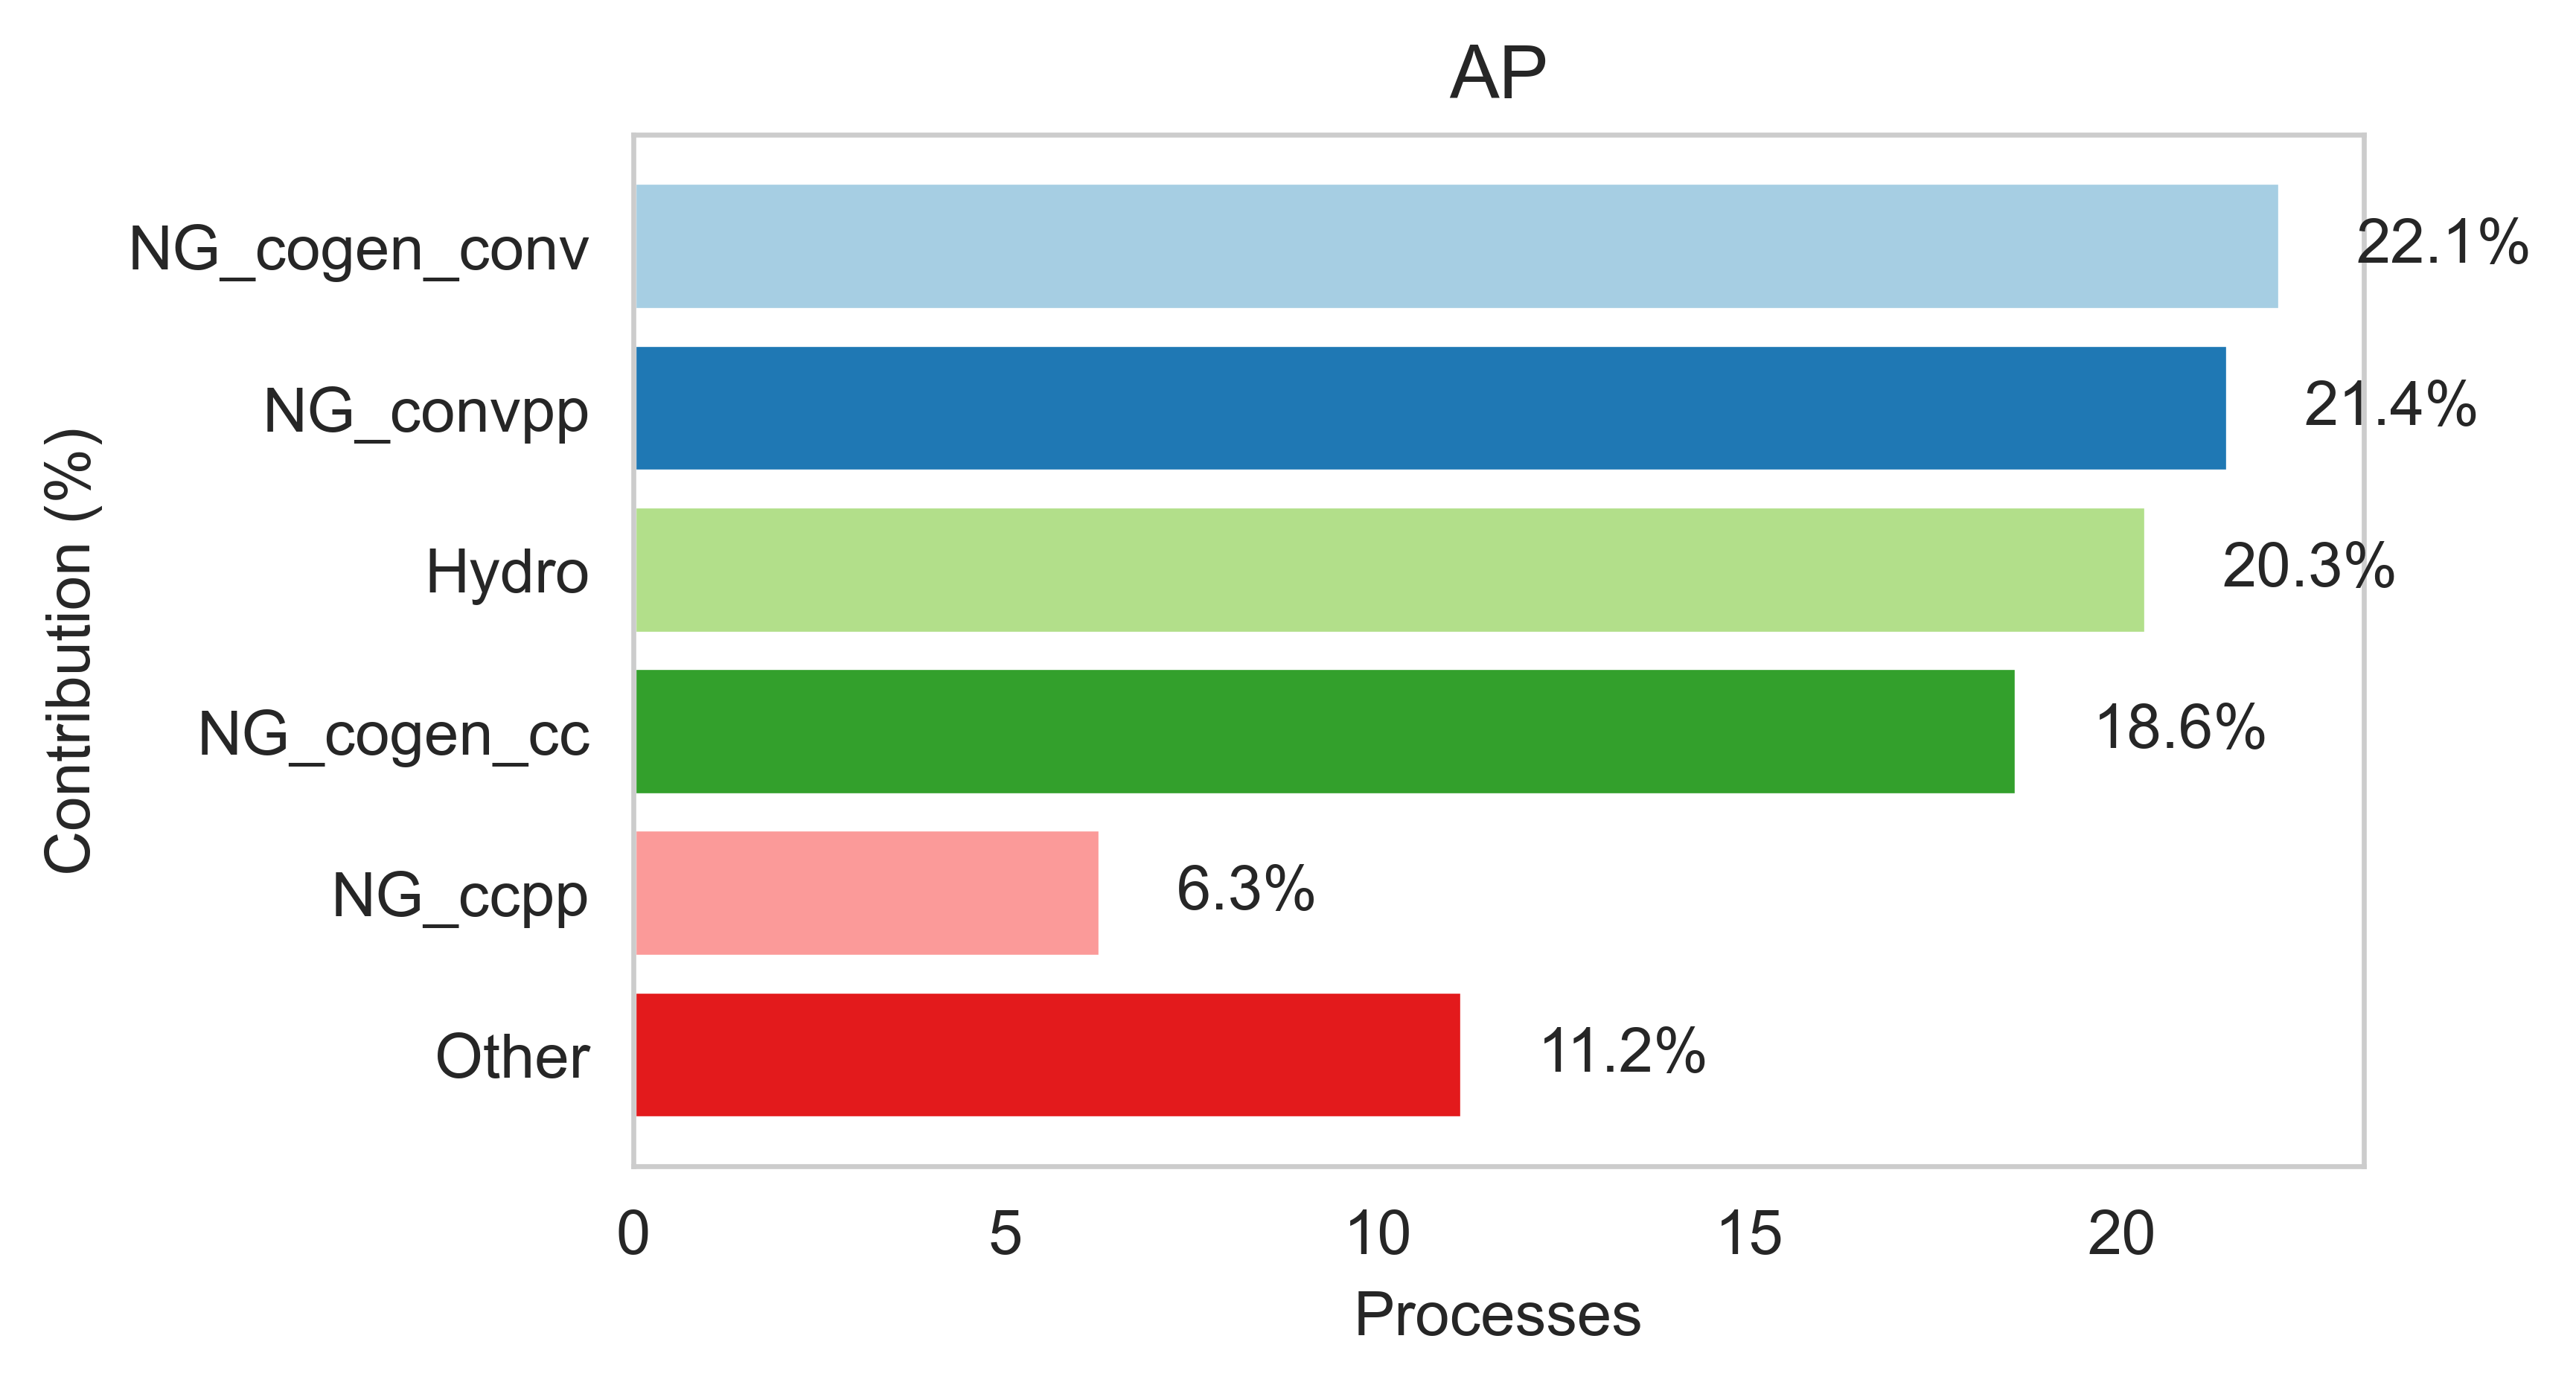

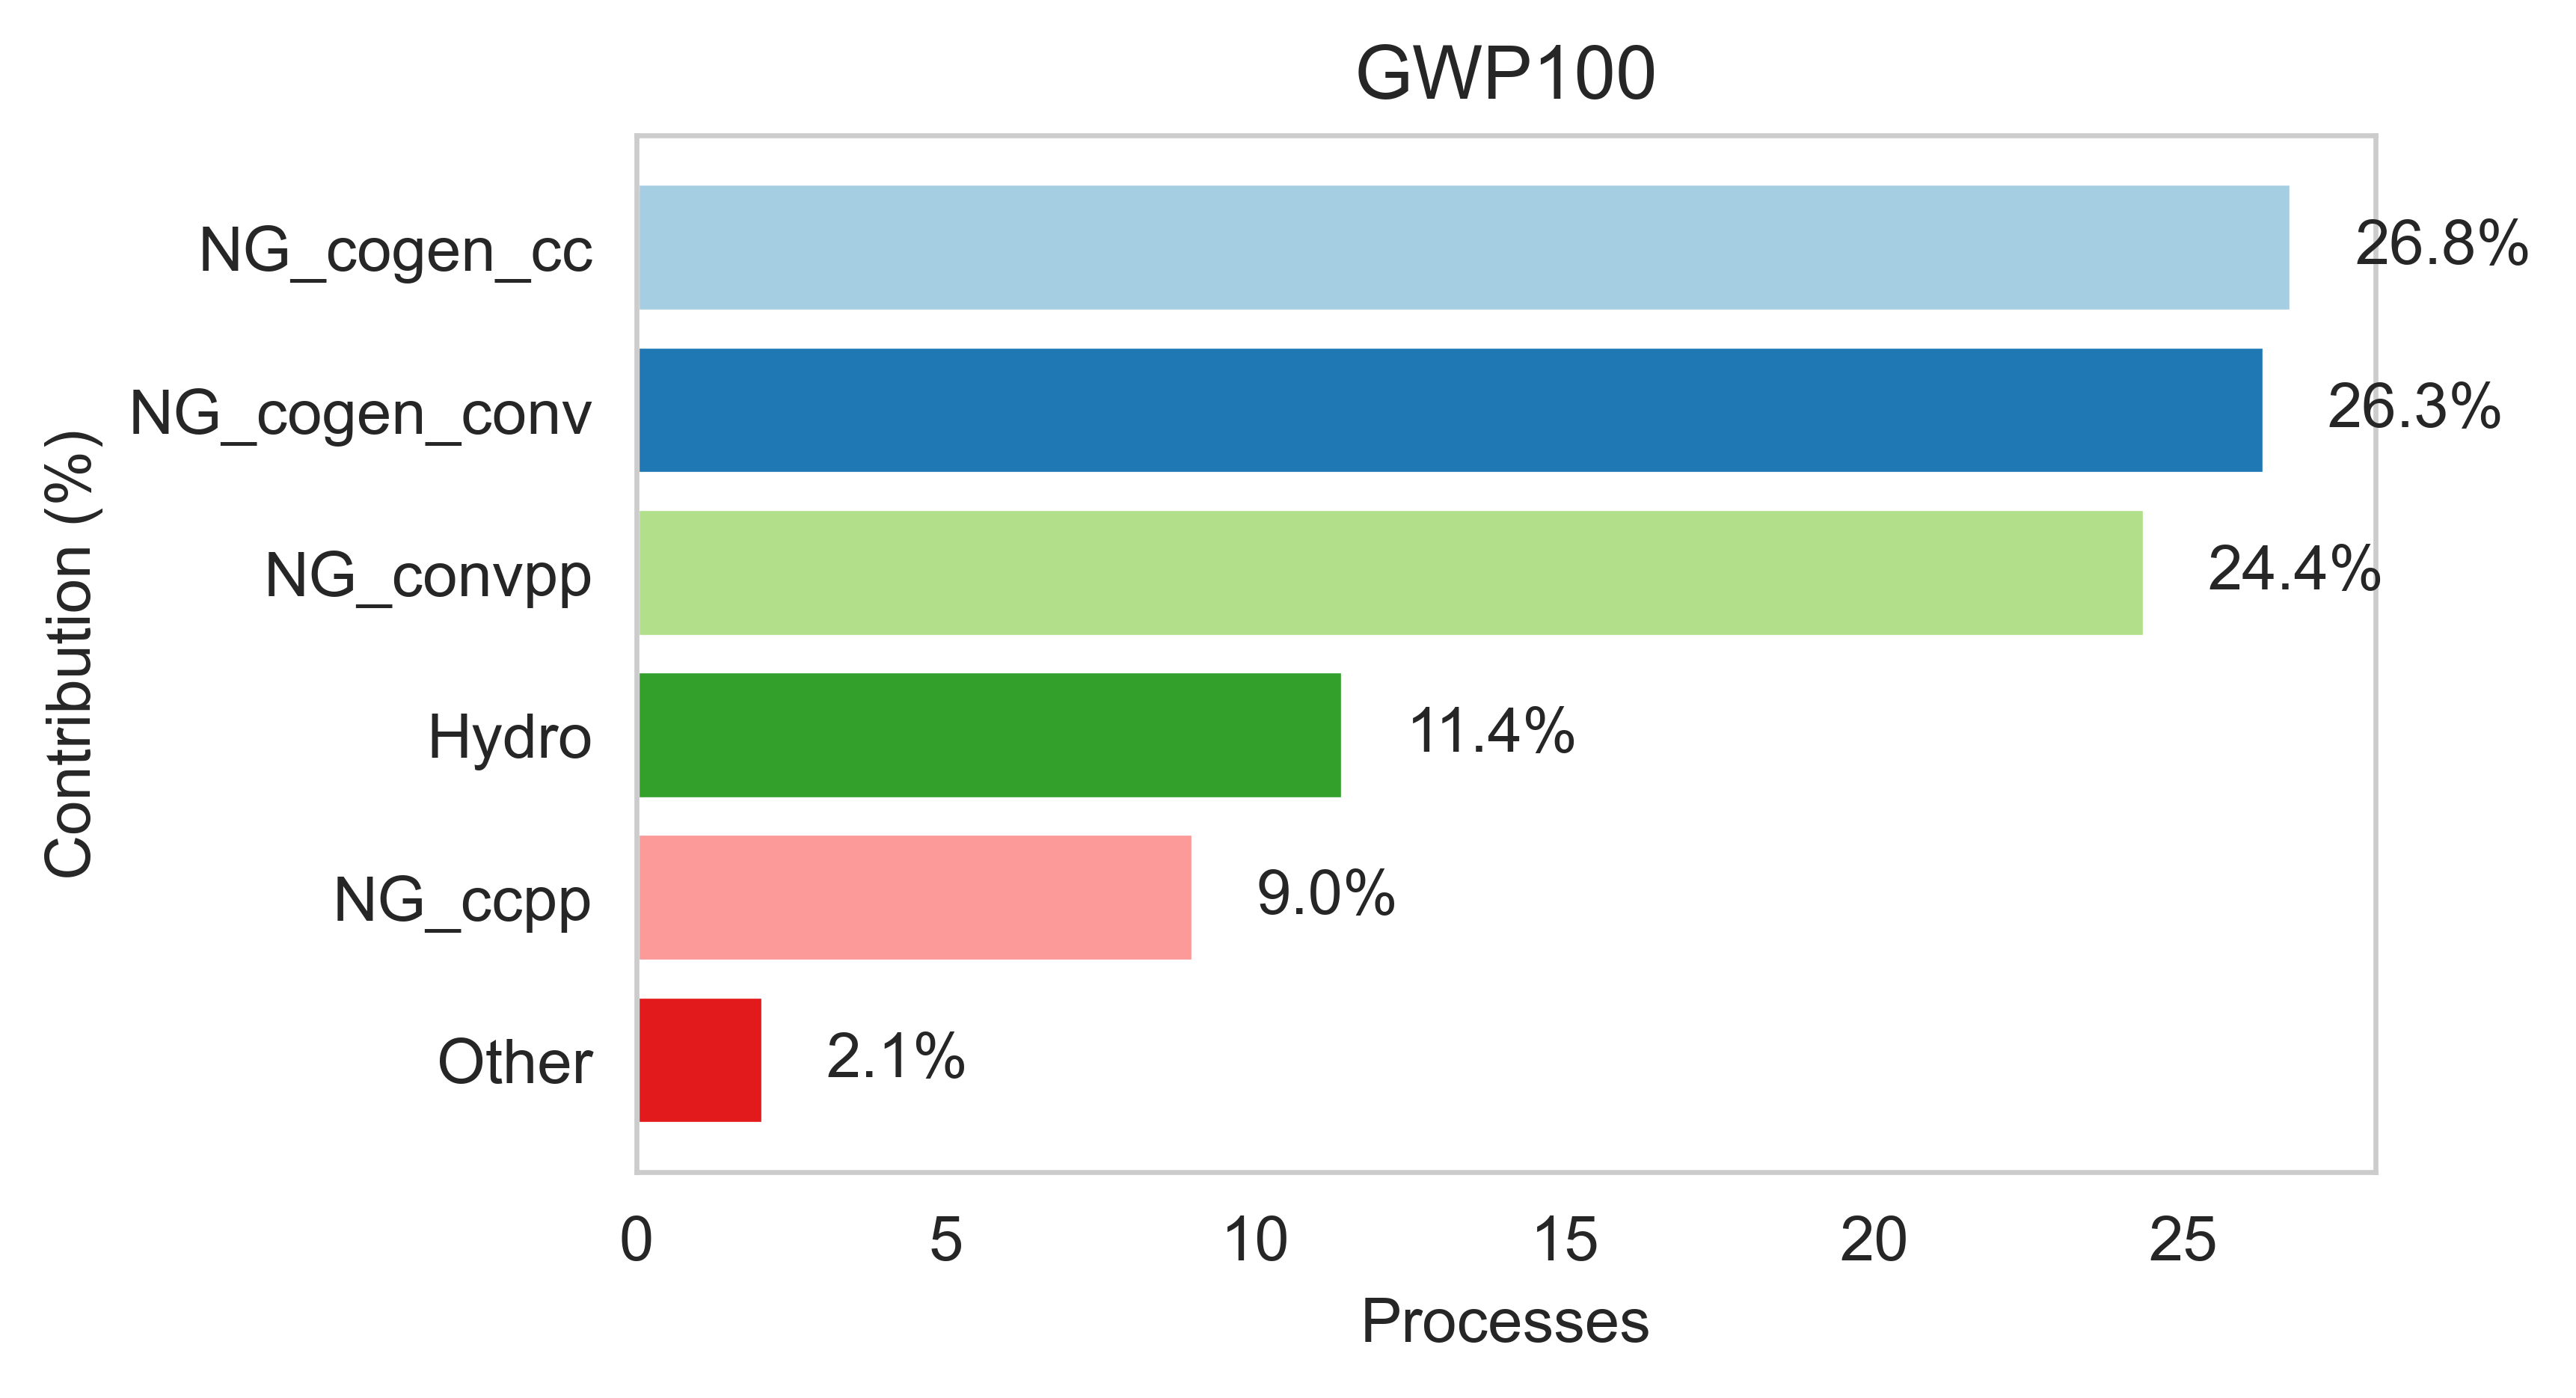

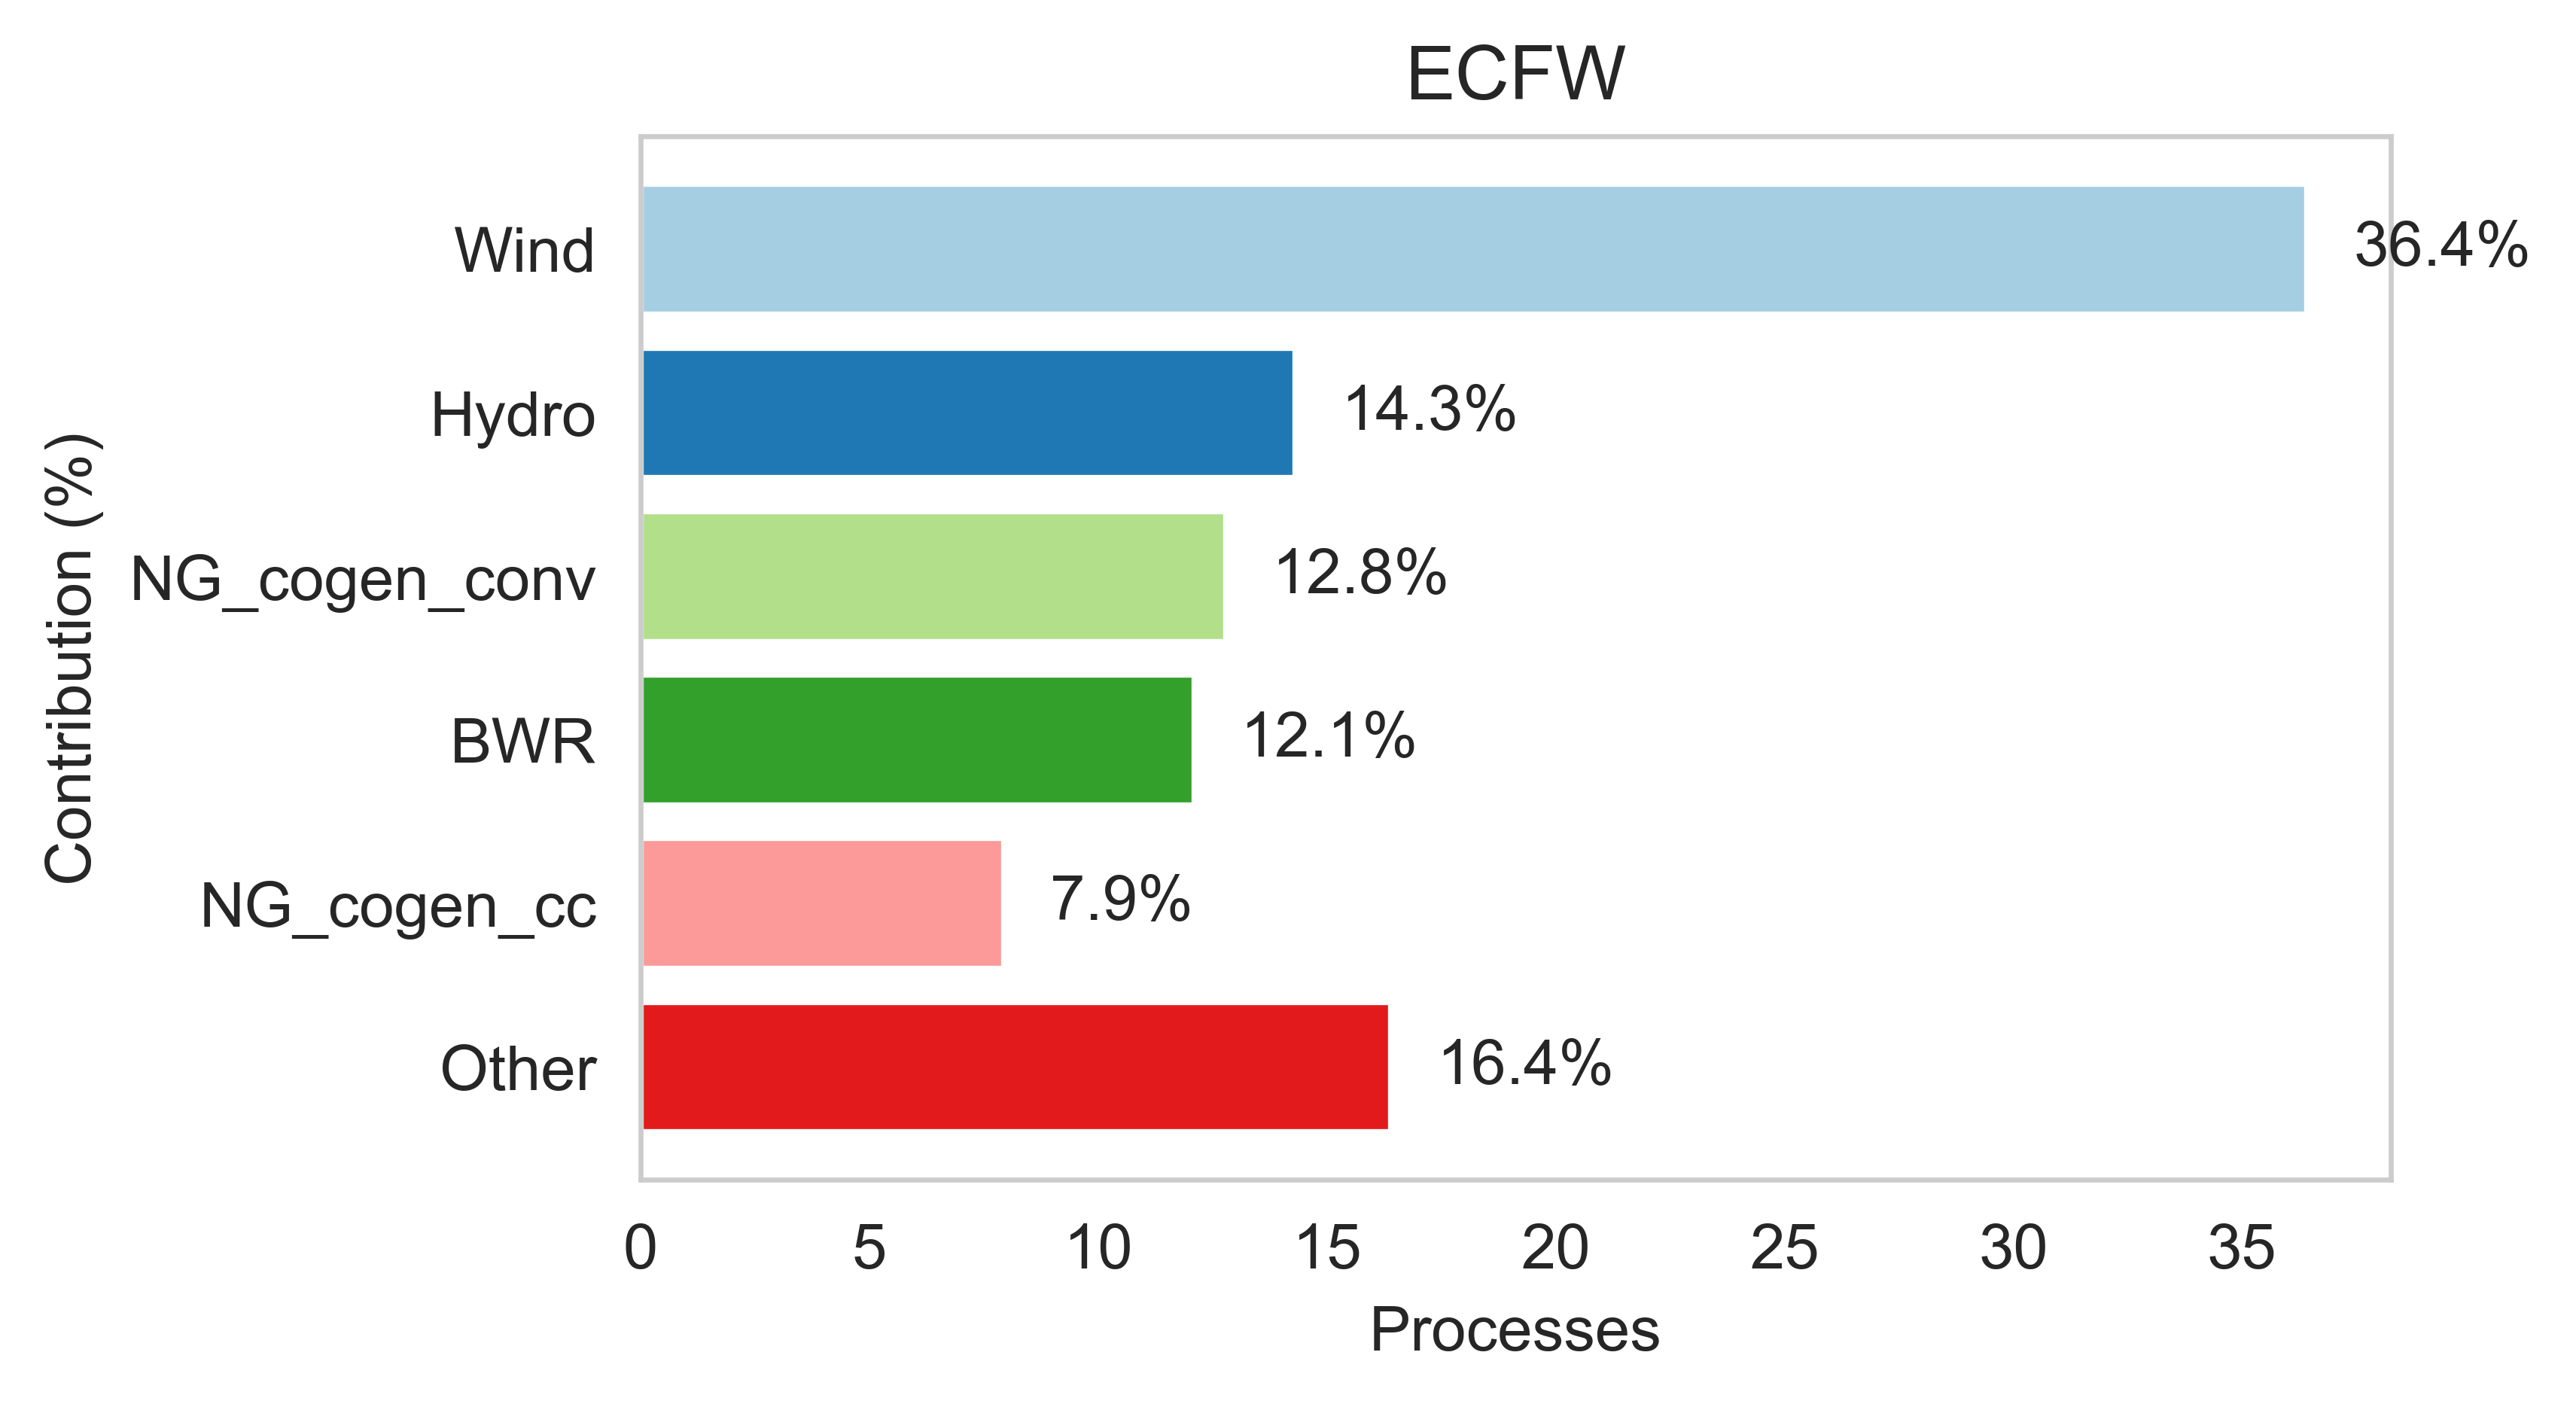

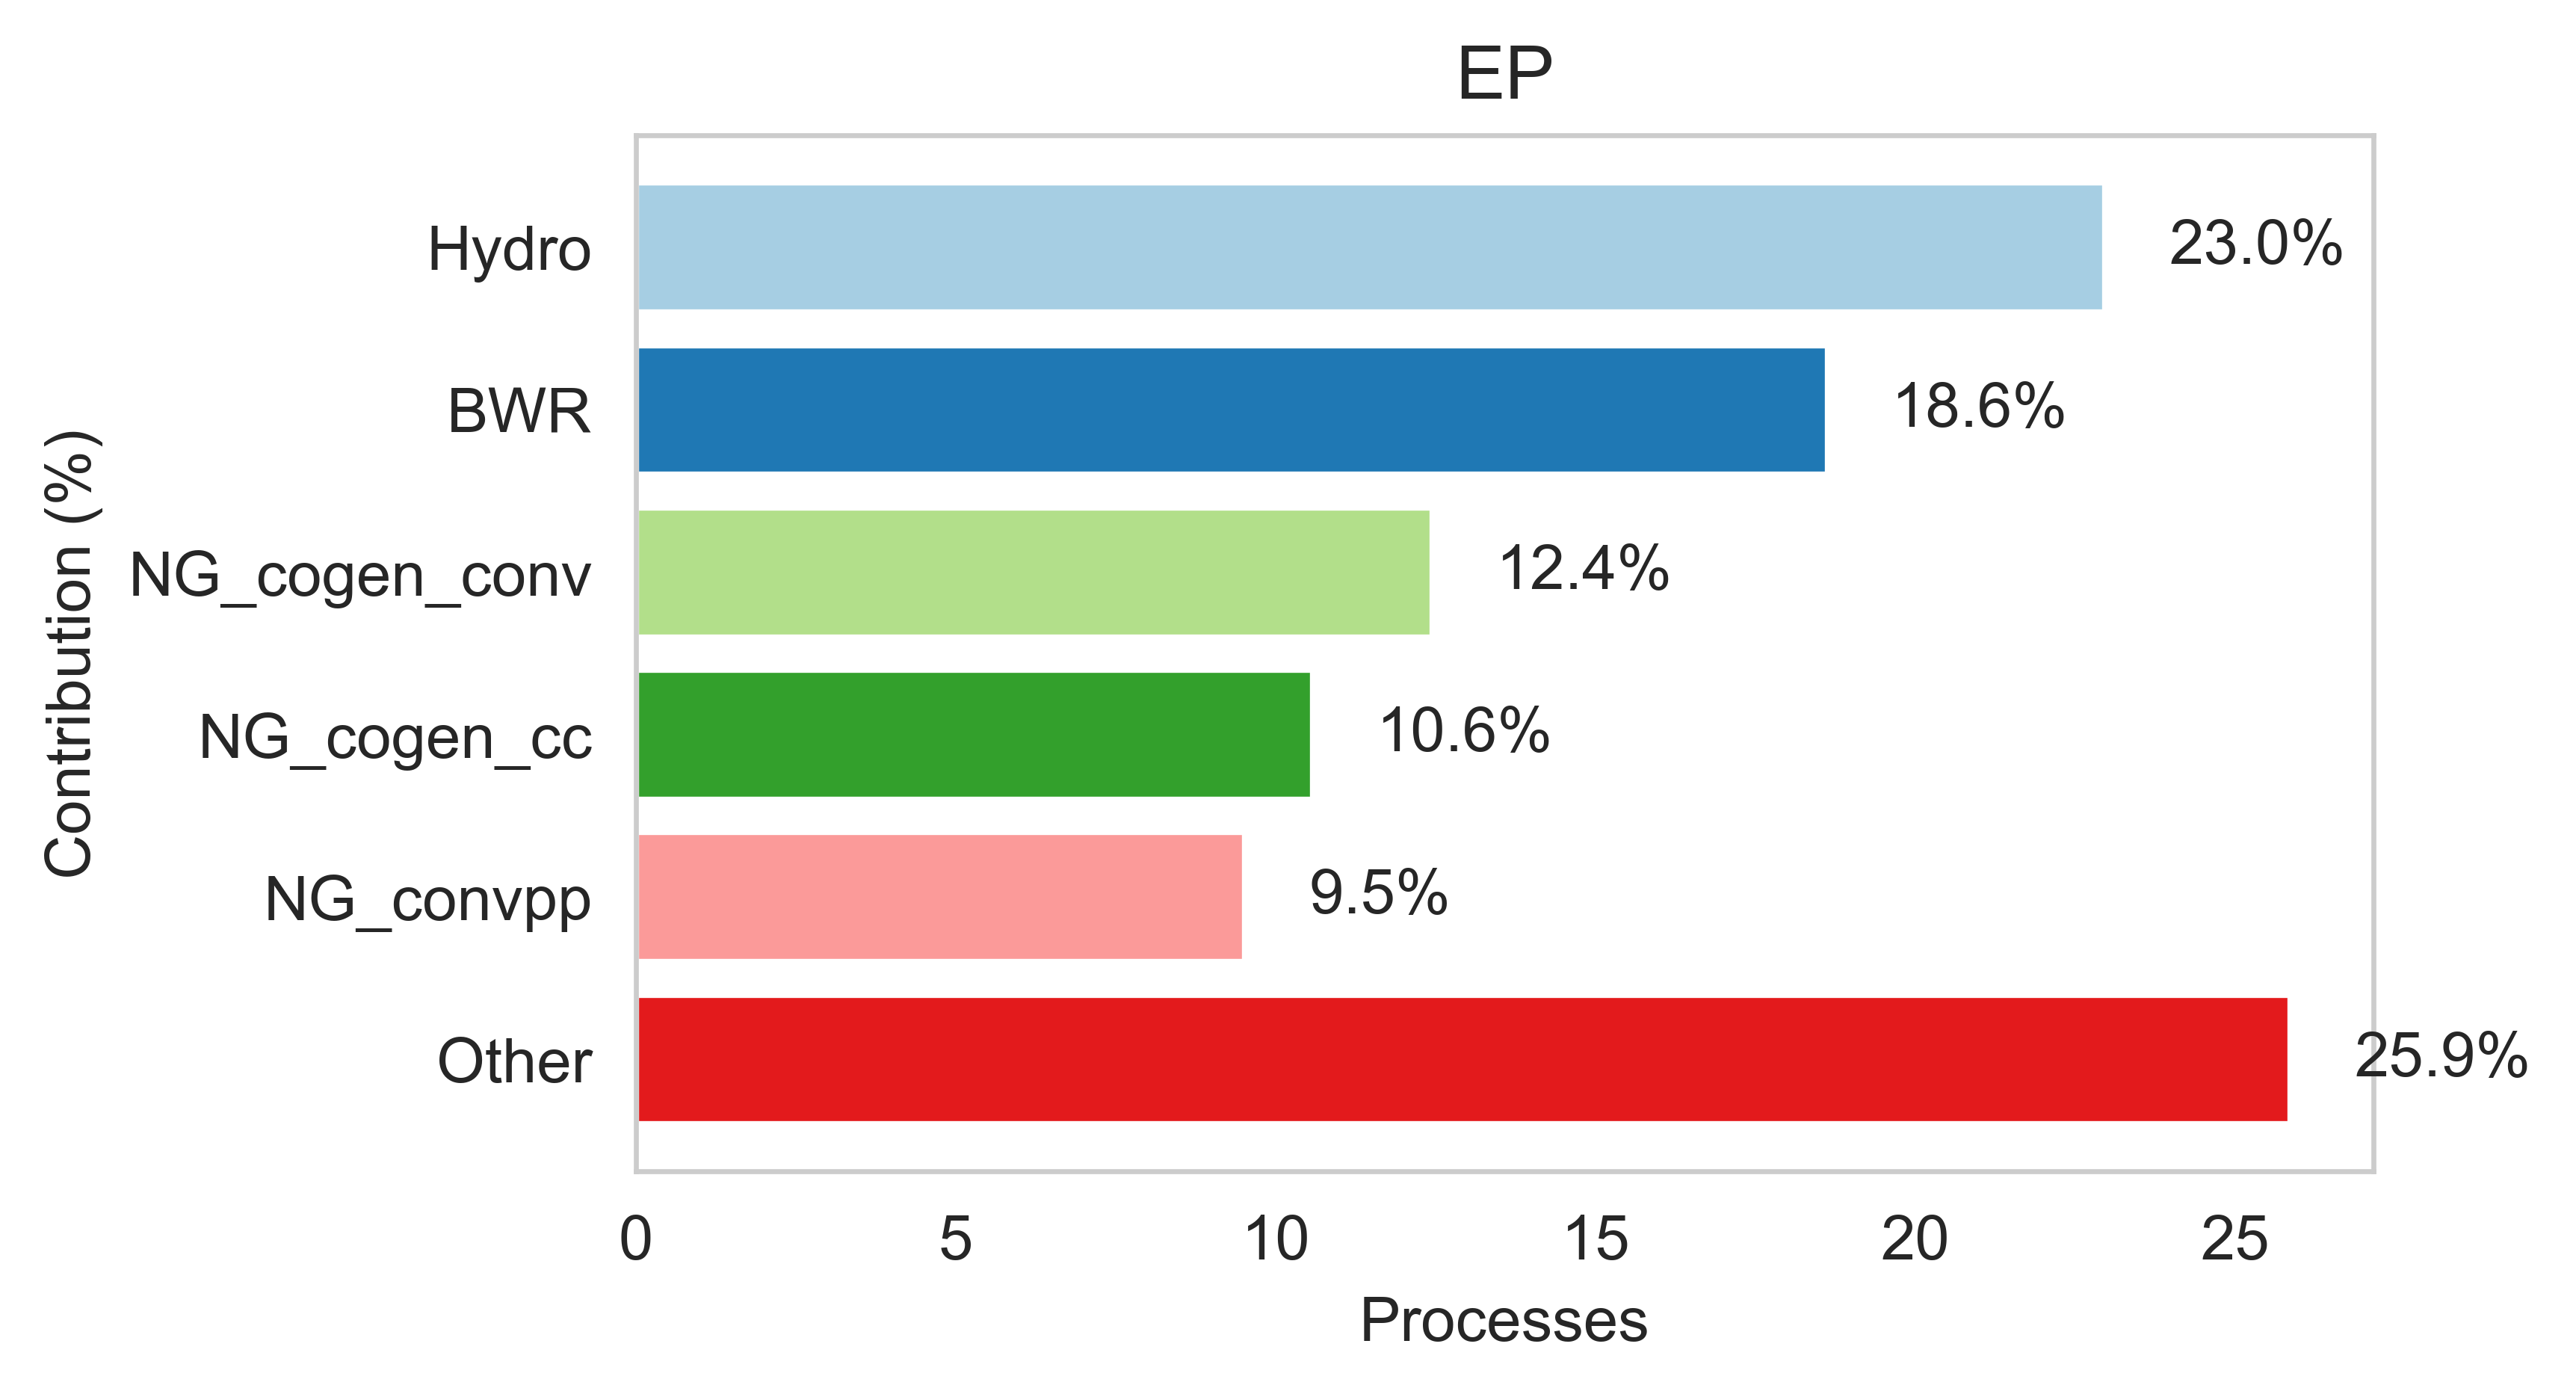

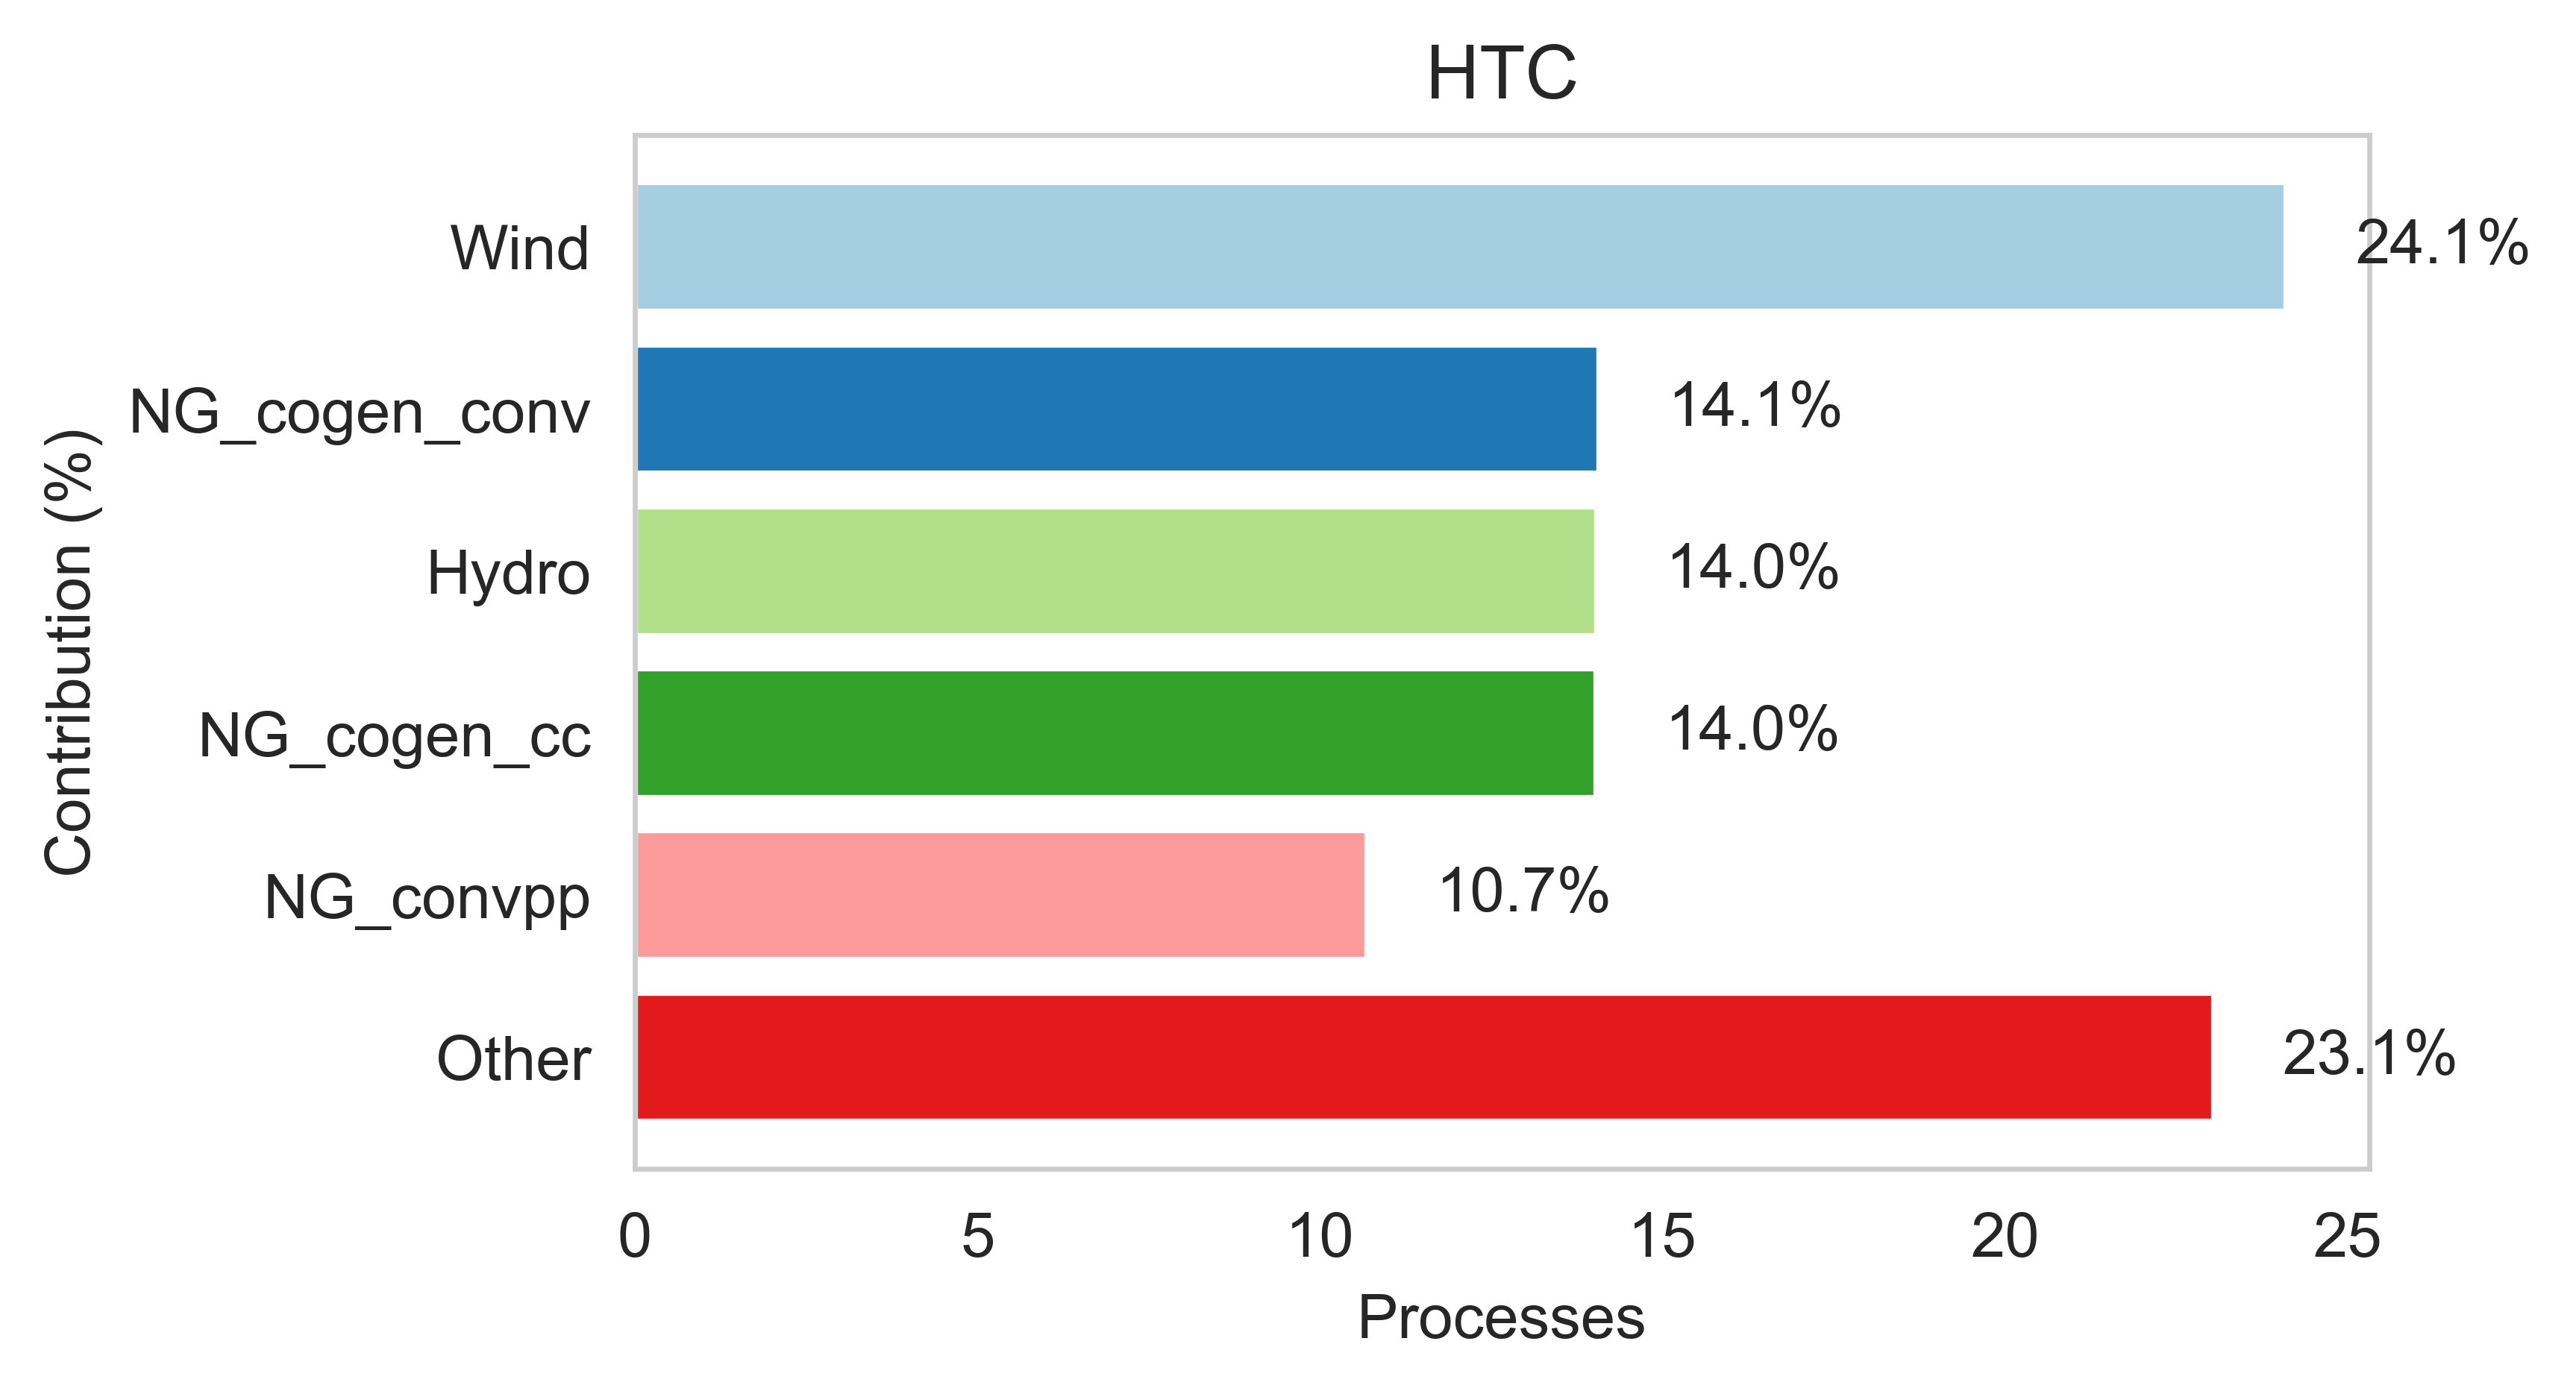

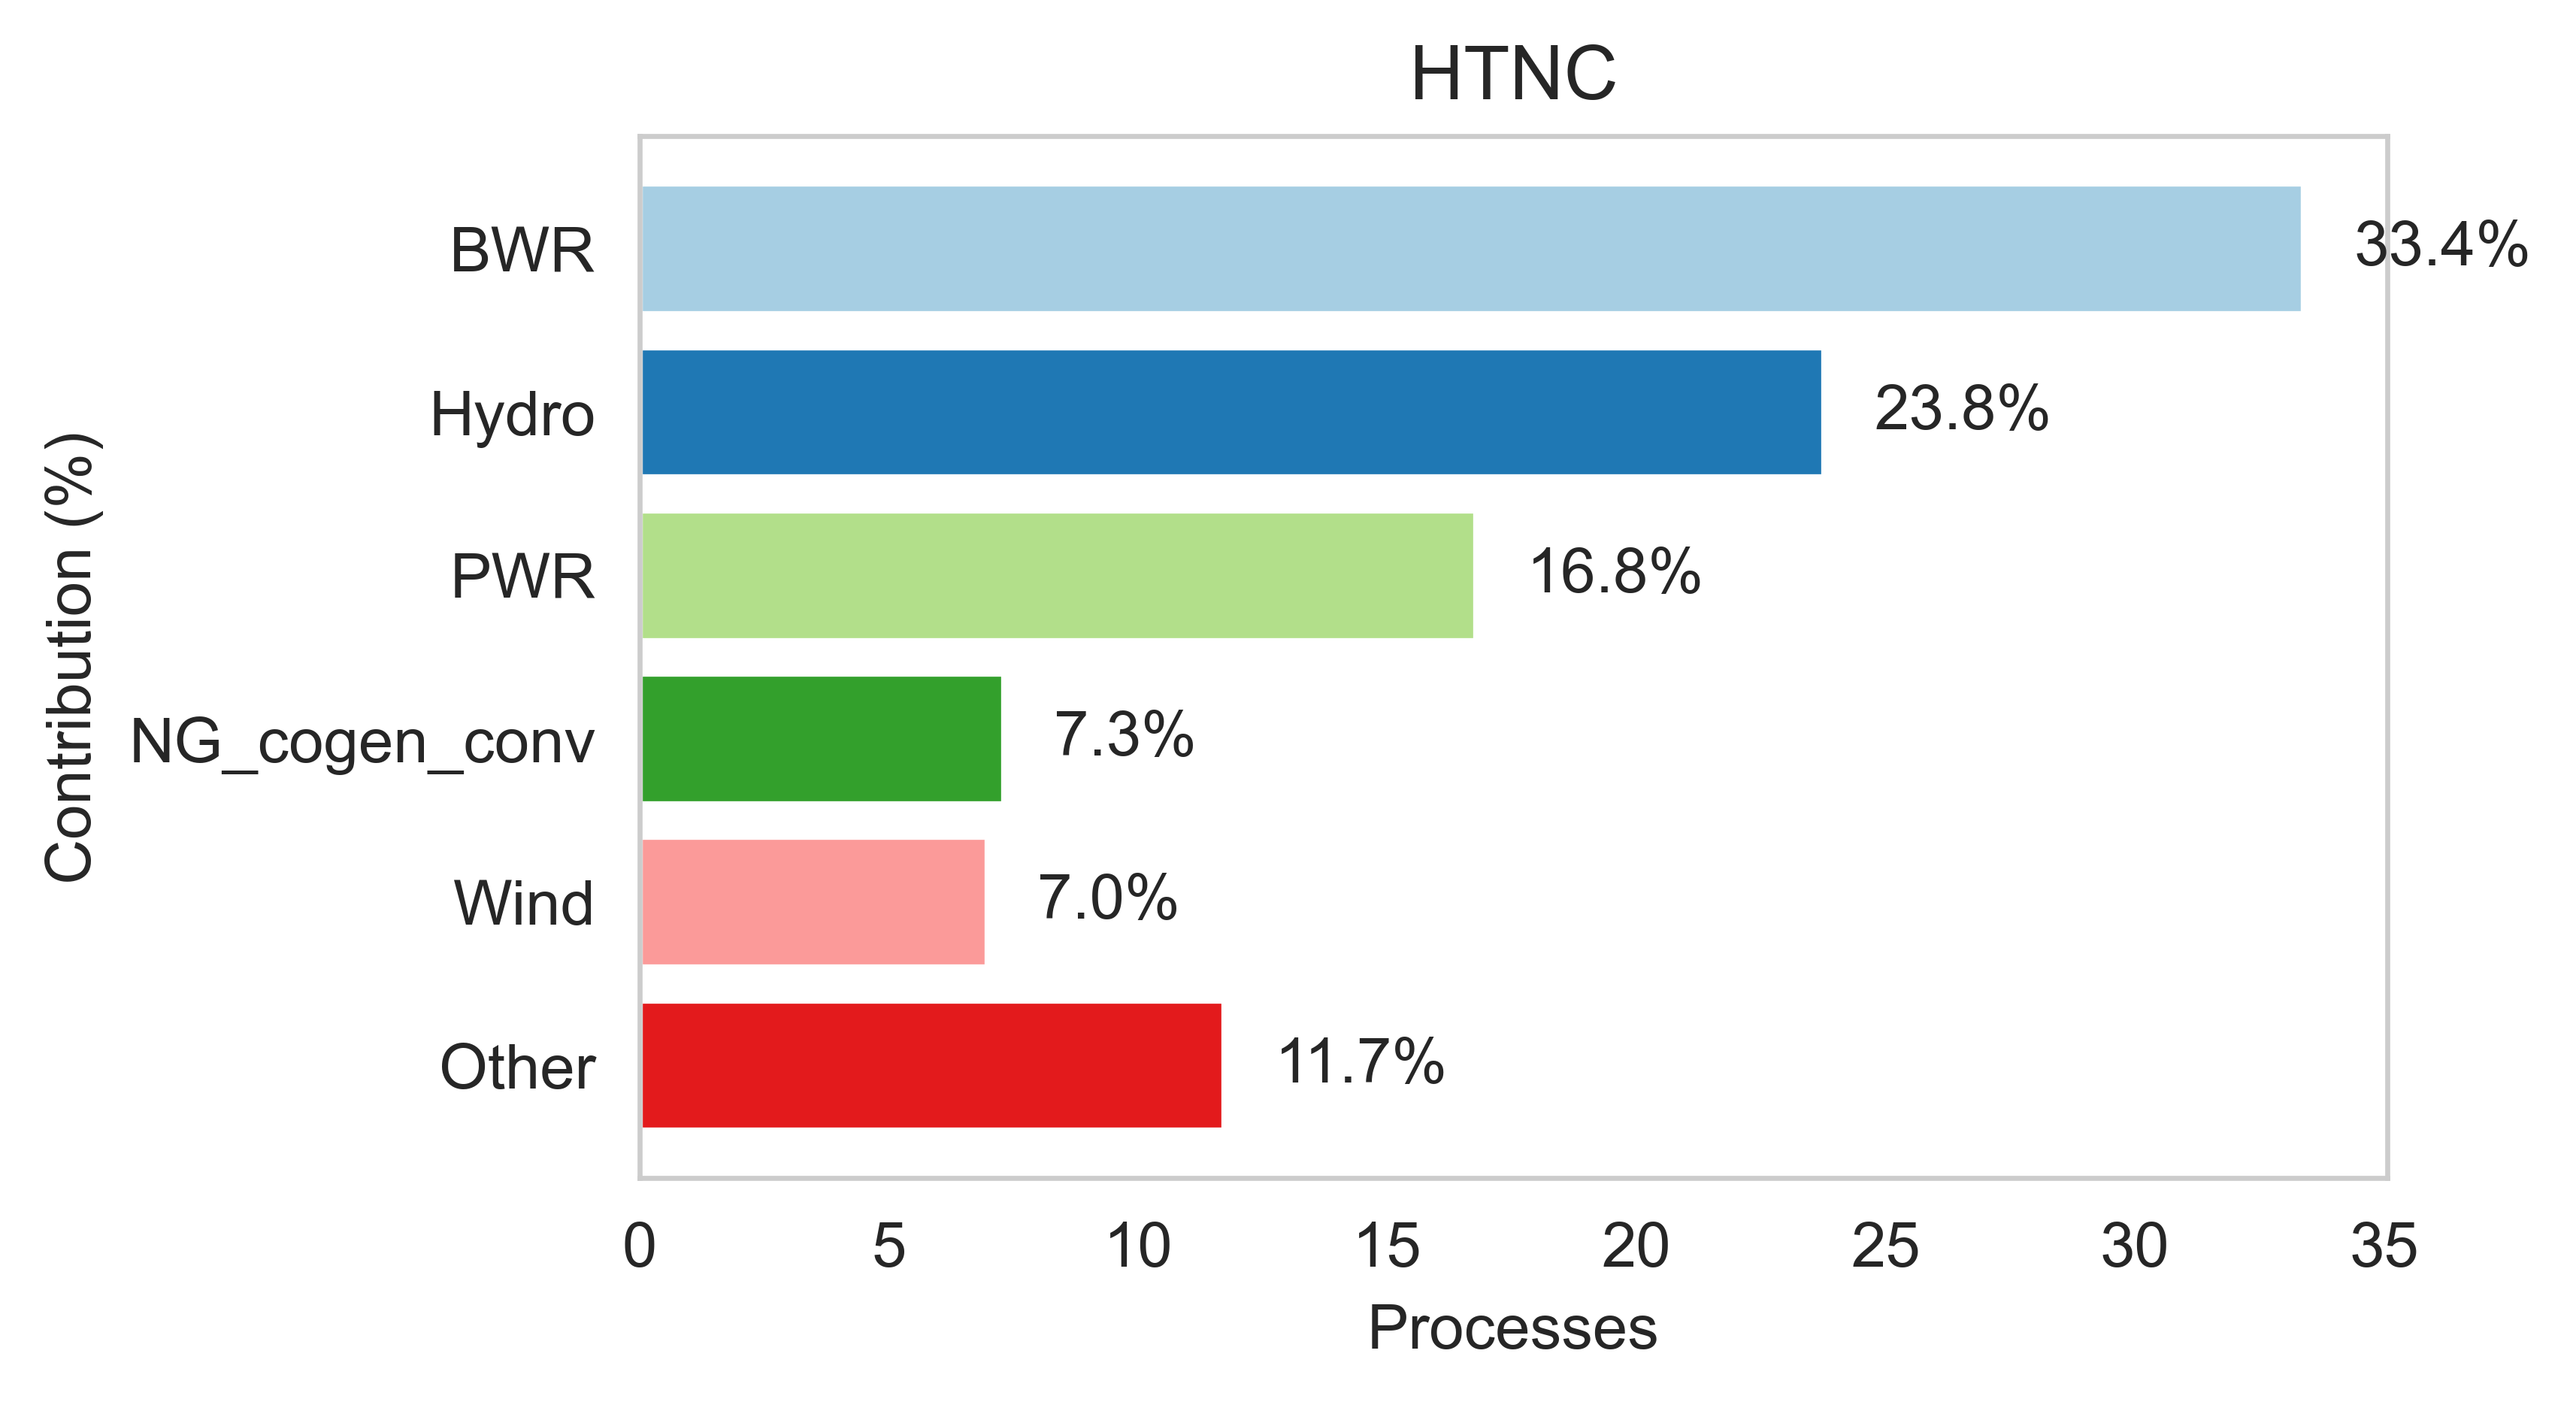

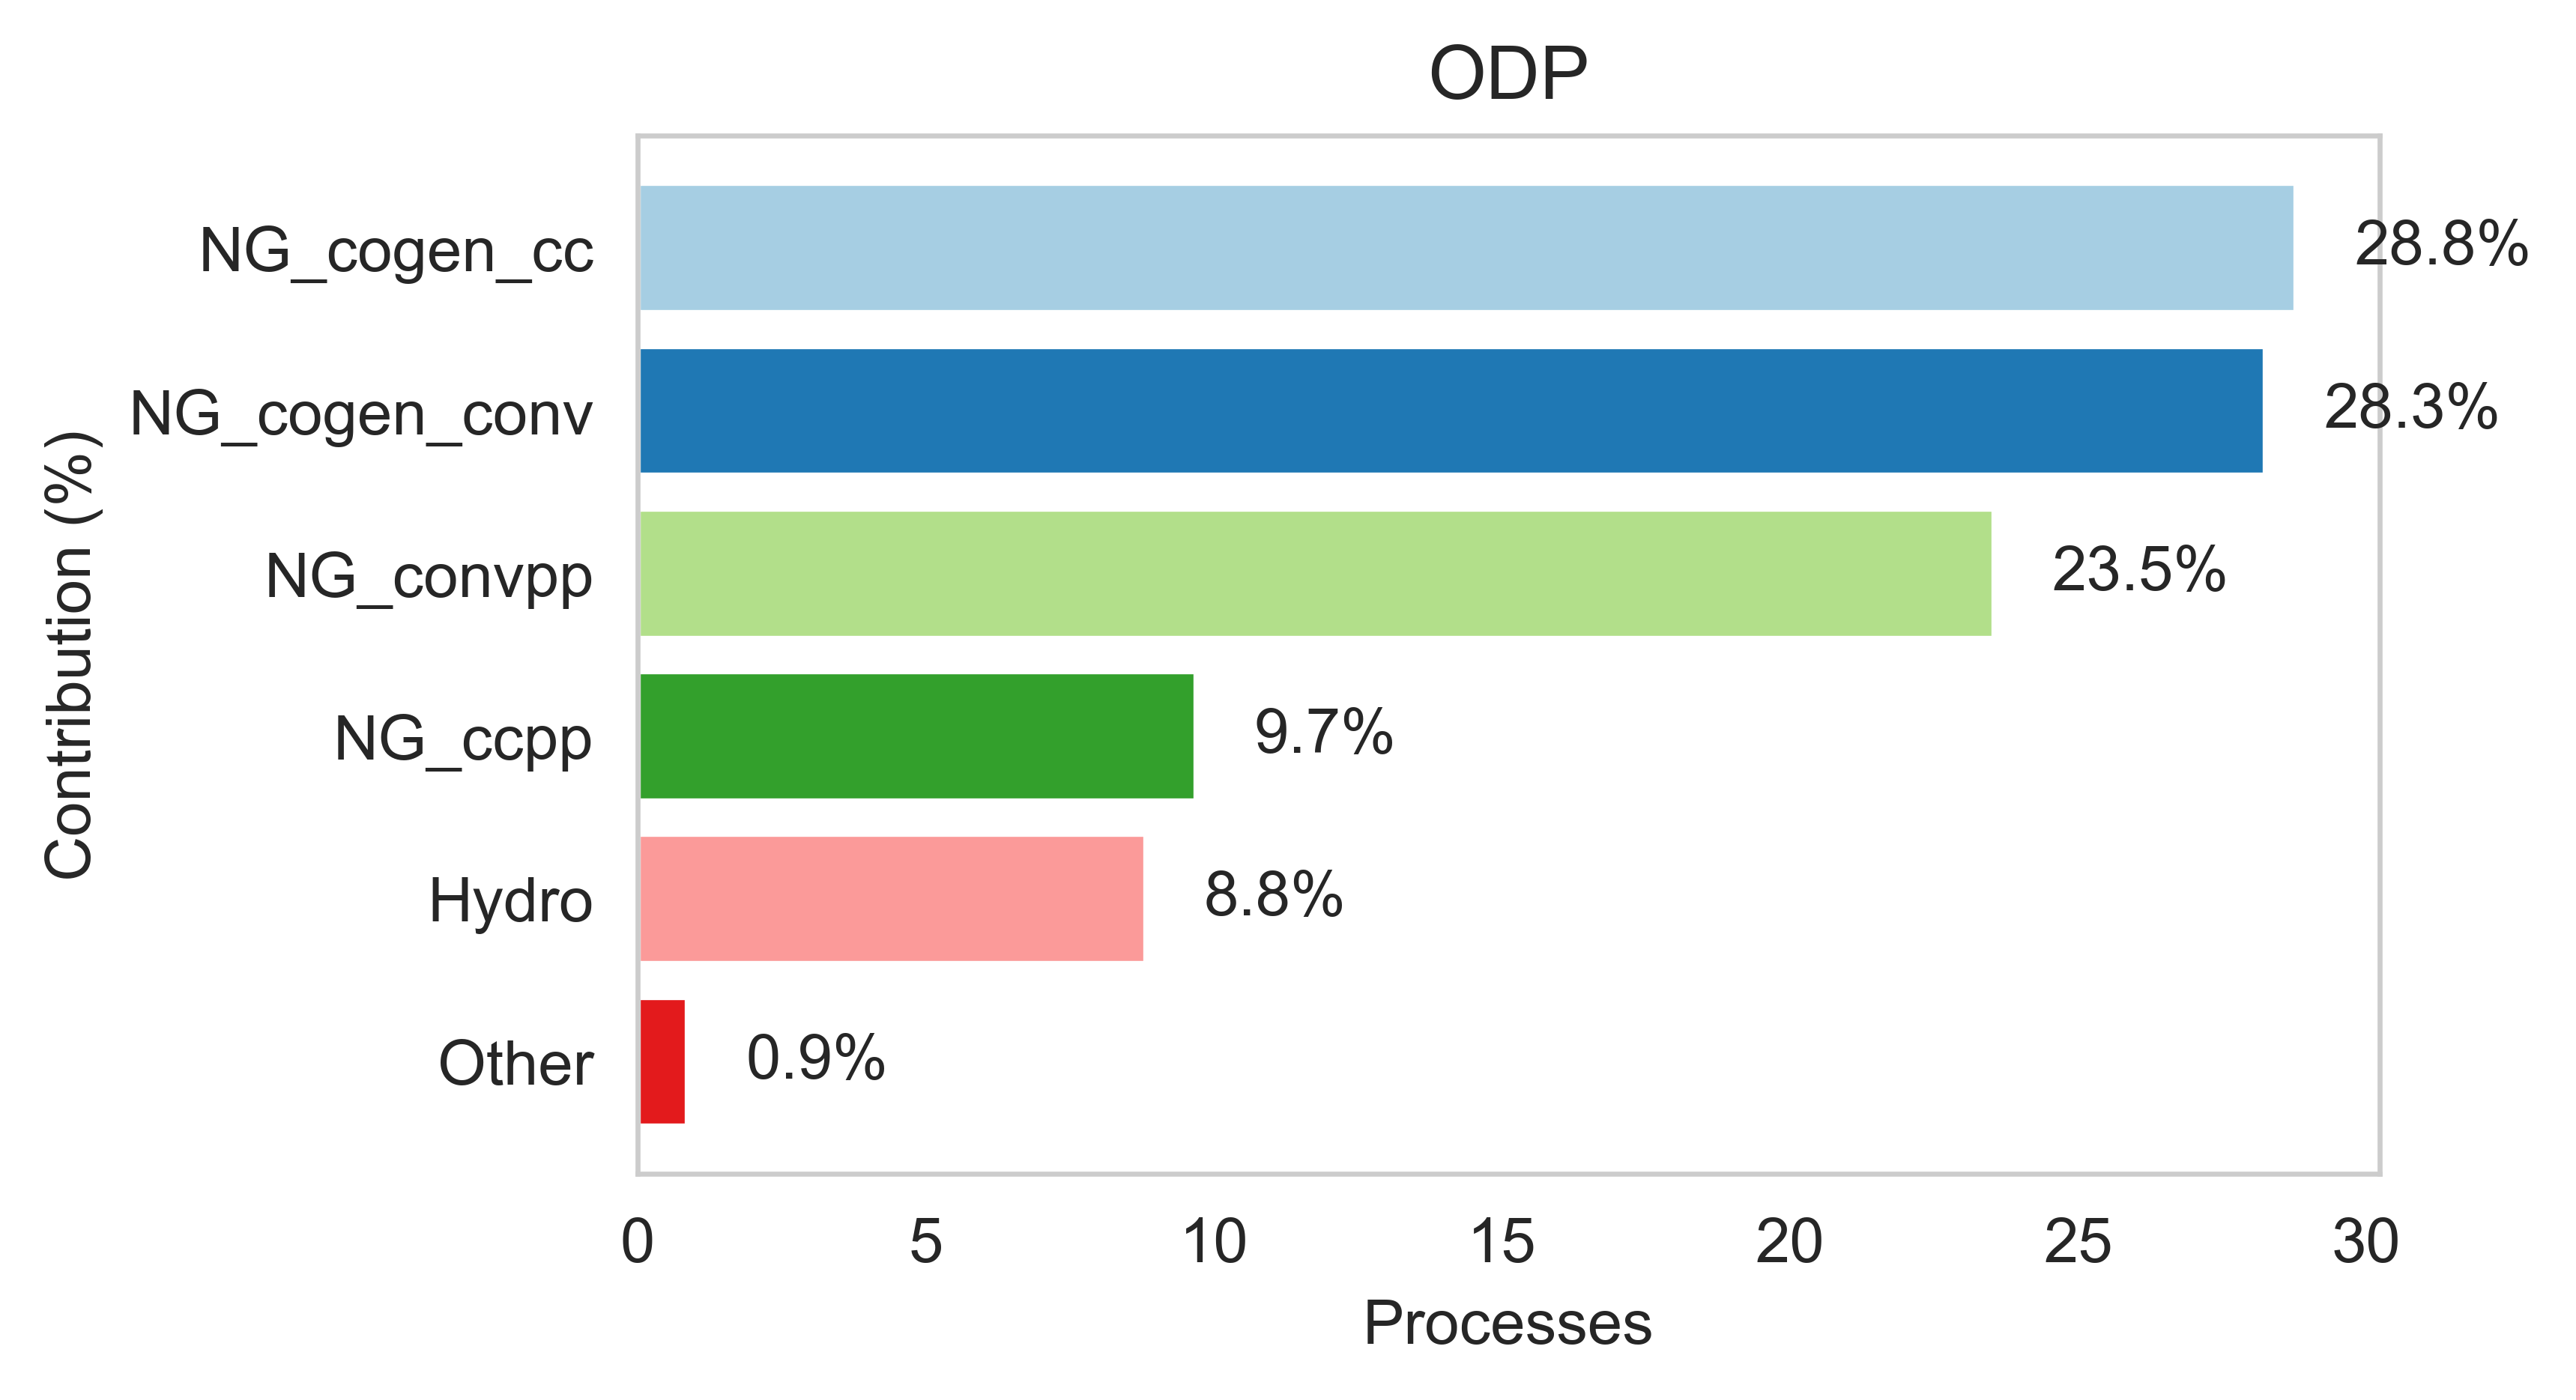

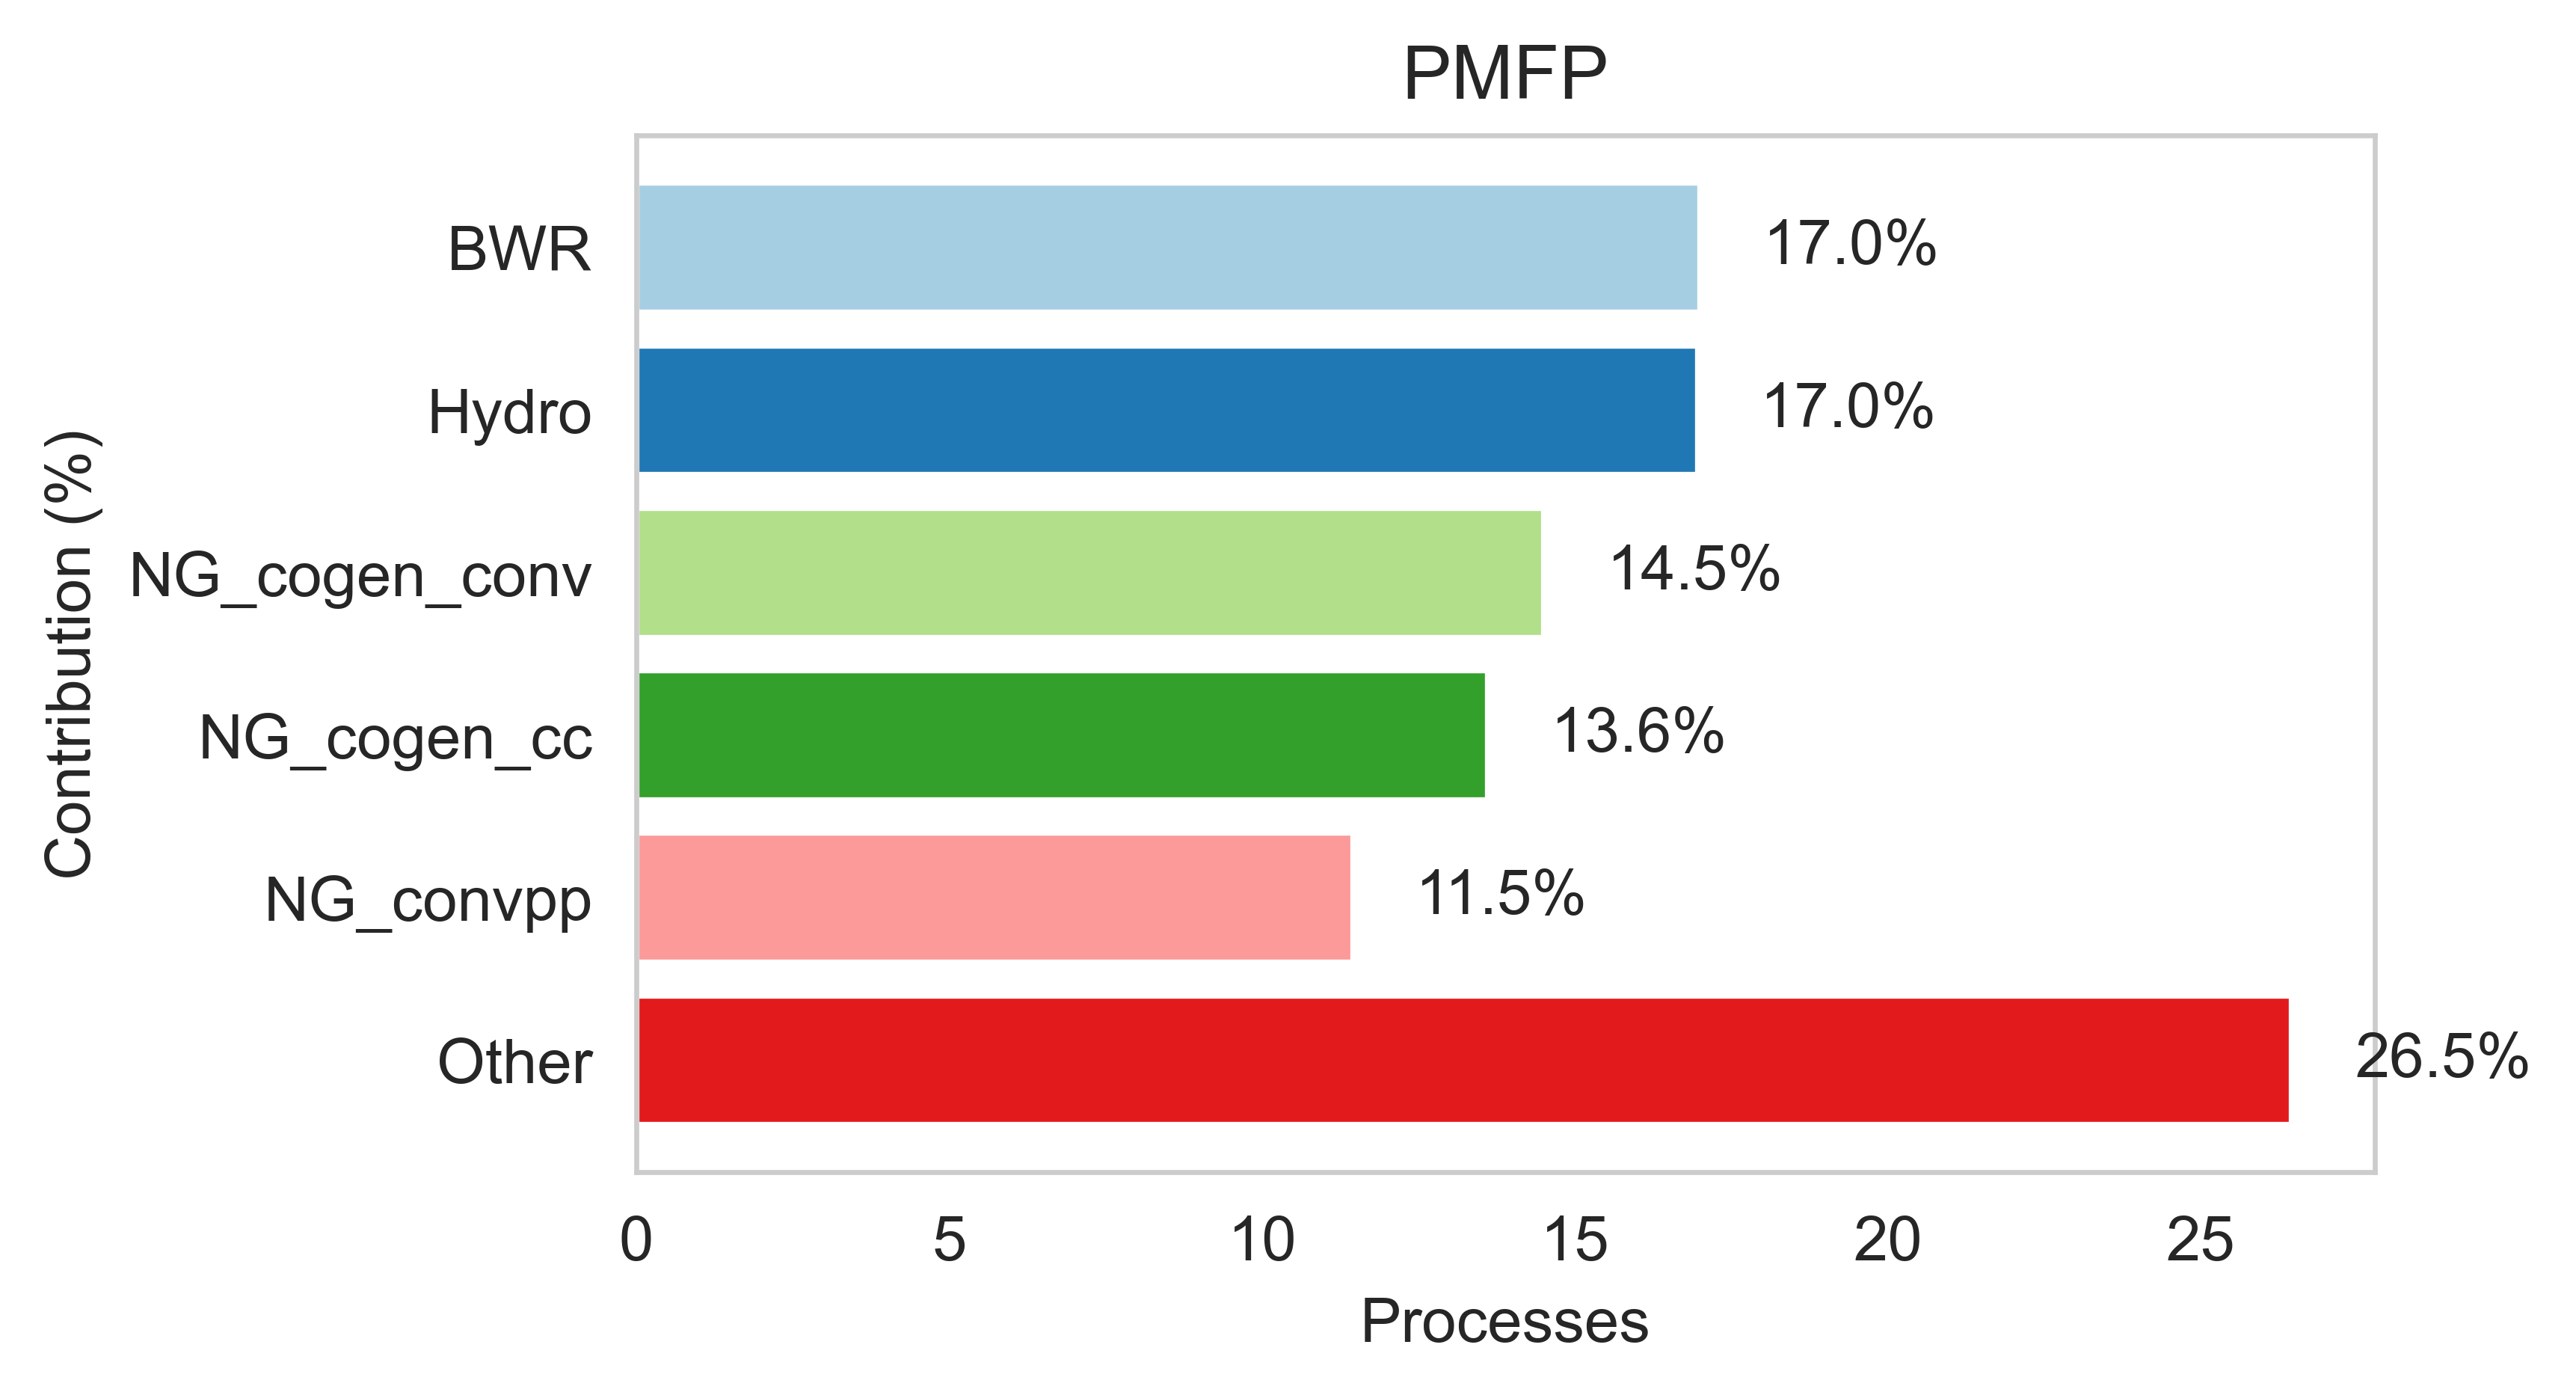

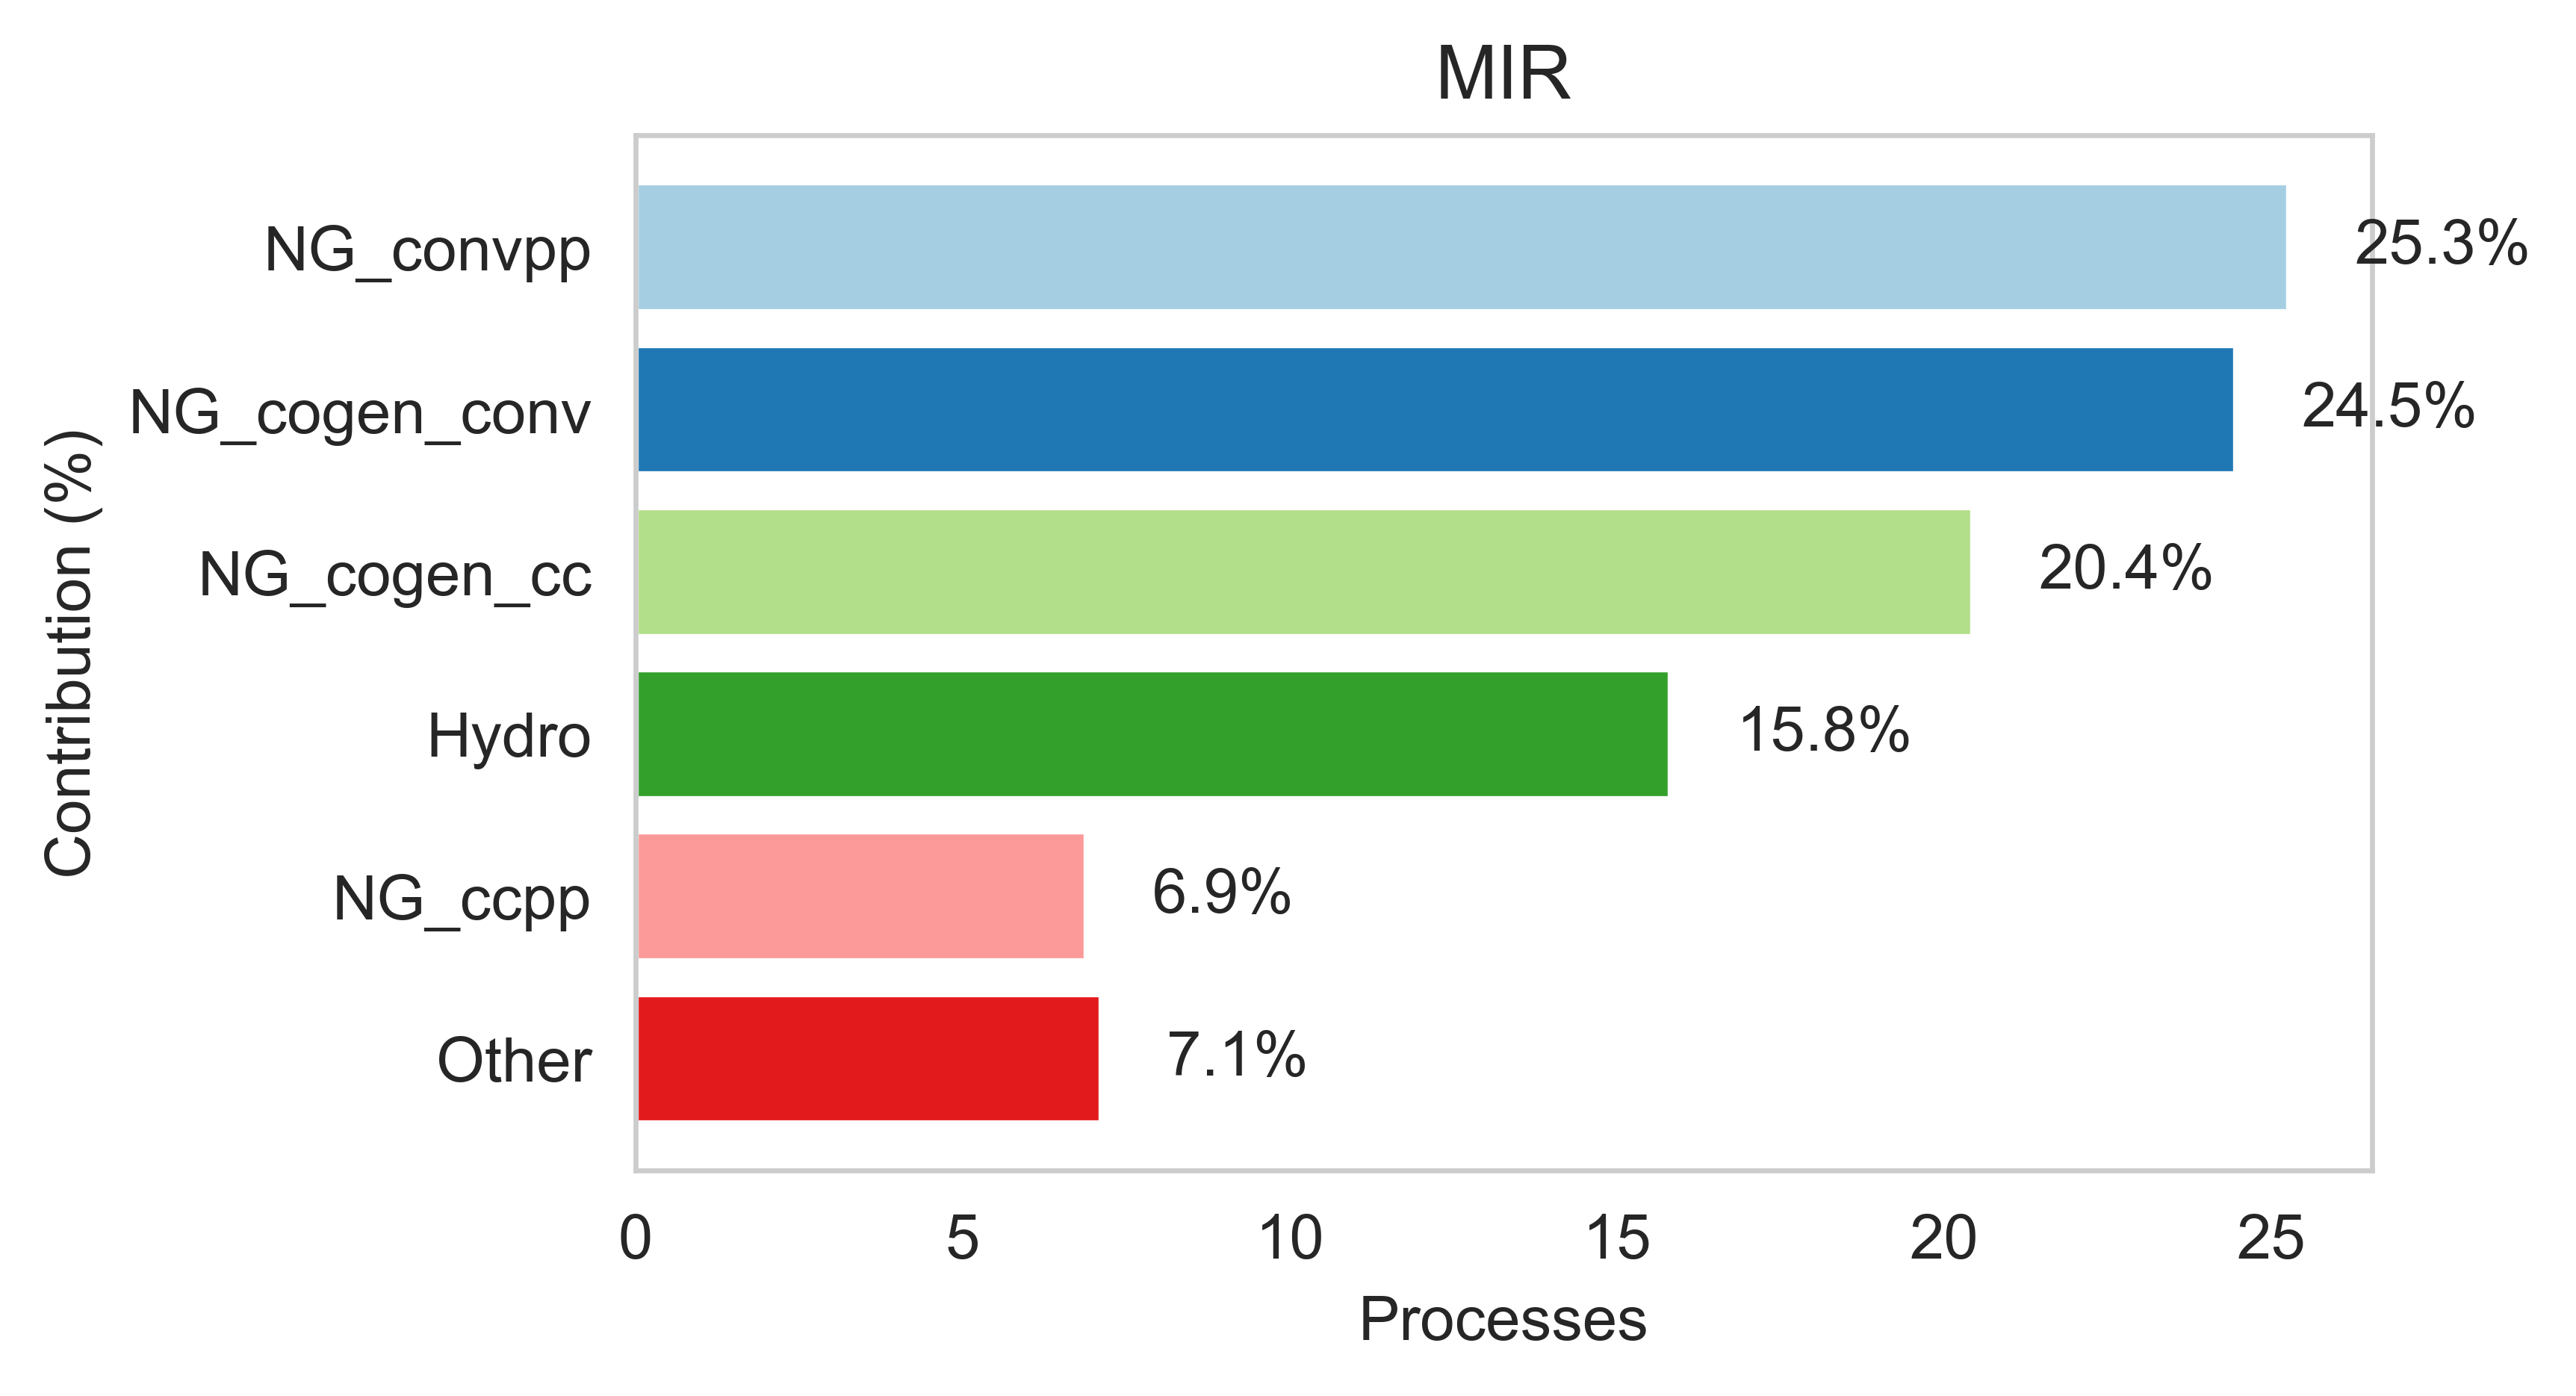

In [54]:
temp_list = list(dict_with_contribution_dfs.keys())

for cat in ['AP', 'GWP100', 'ECFW', 'EP', 'HTC', 'HTNC', 'ODP', 'PMFP', 'MIR']:
    figure_file_path = os.path.join(target_dir, f"sub_process_contributions{cat}.png")
    plot_stacked_percentage_bar_sub_processes(sp_results_handler.contribution_per_sub_sub_process, cat, figure_file_path, verbose = 'False')

Plot and store contribution barcharts per sub-process and for the main process

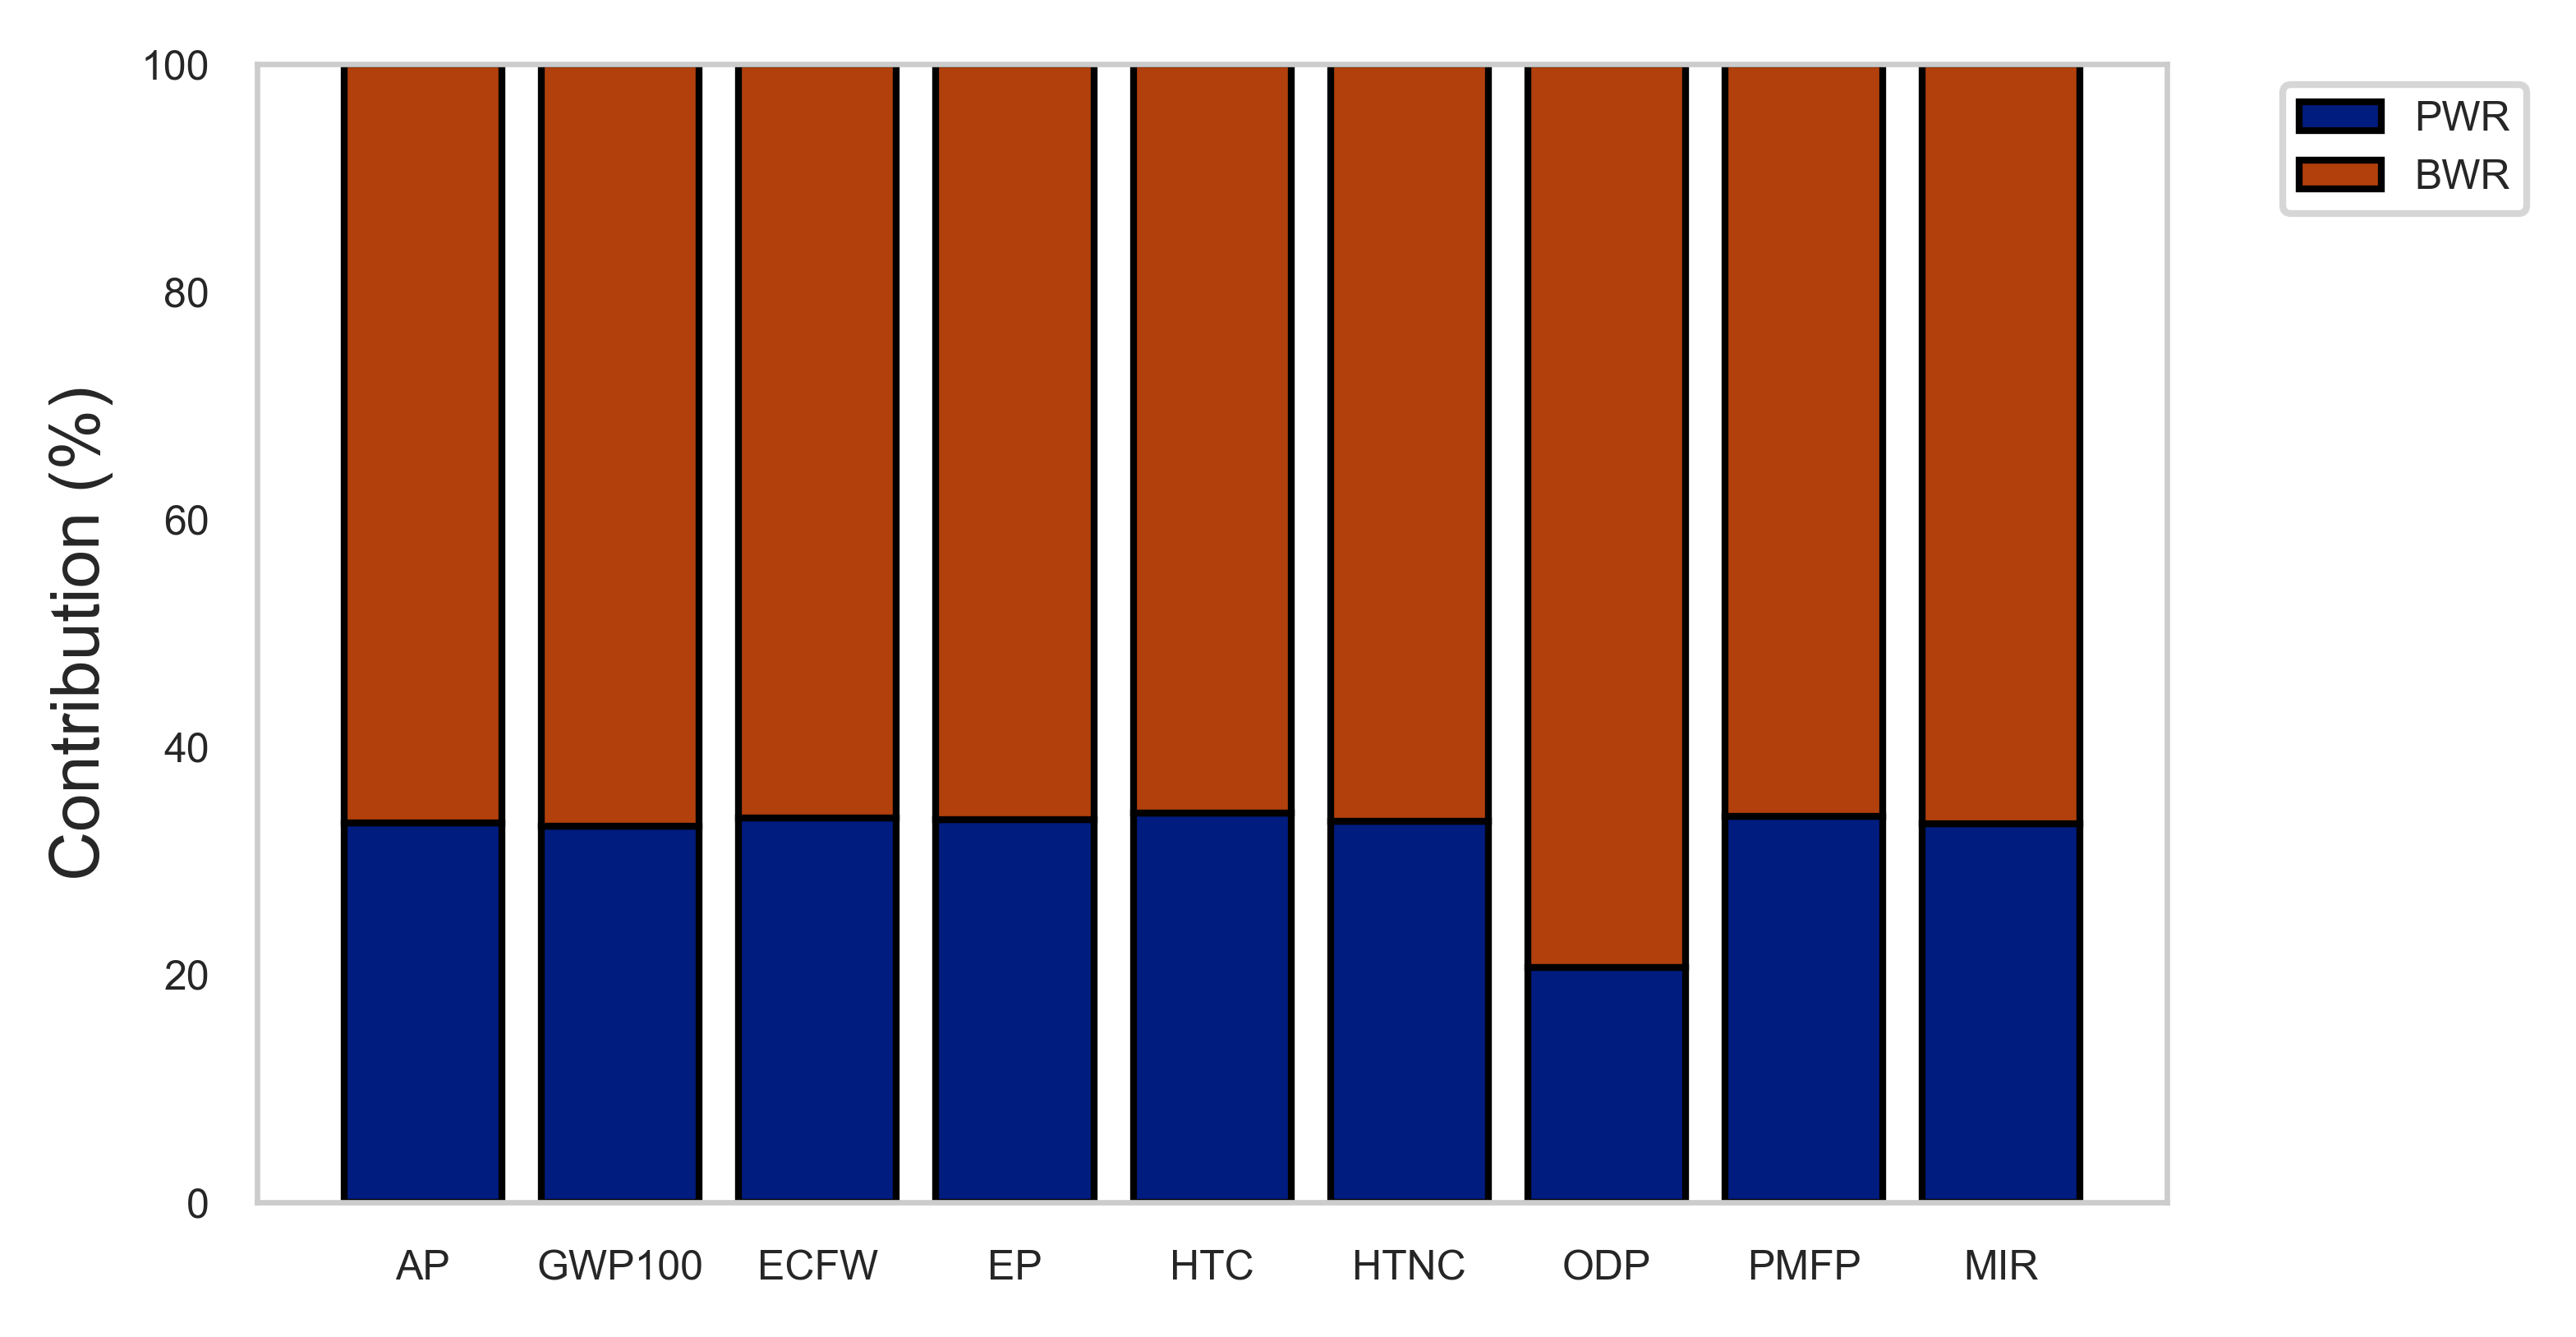

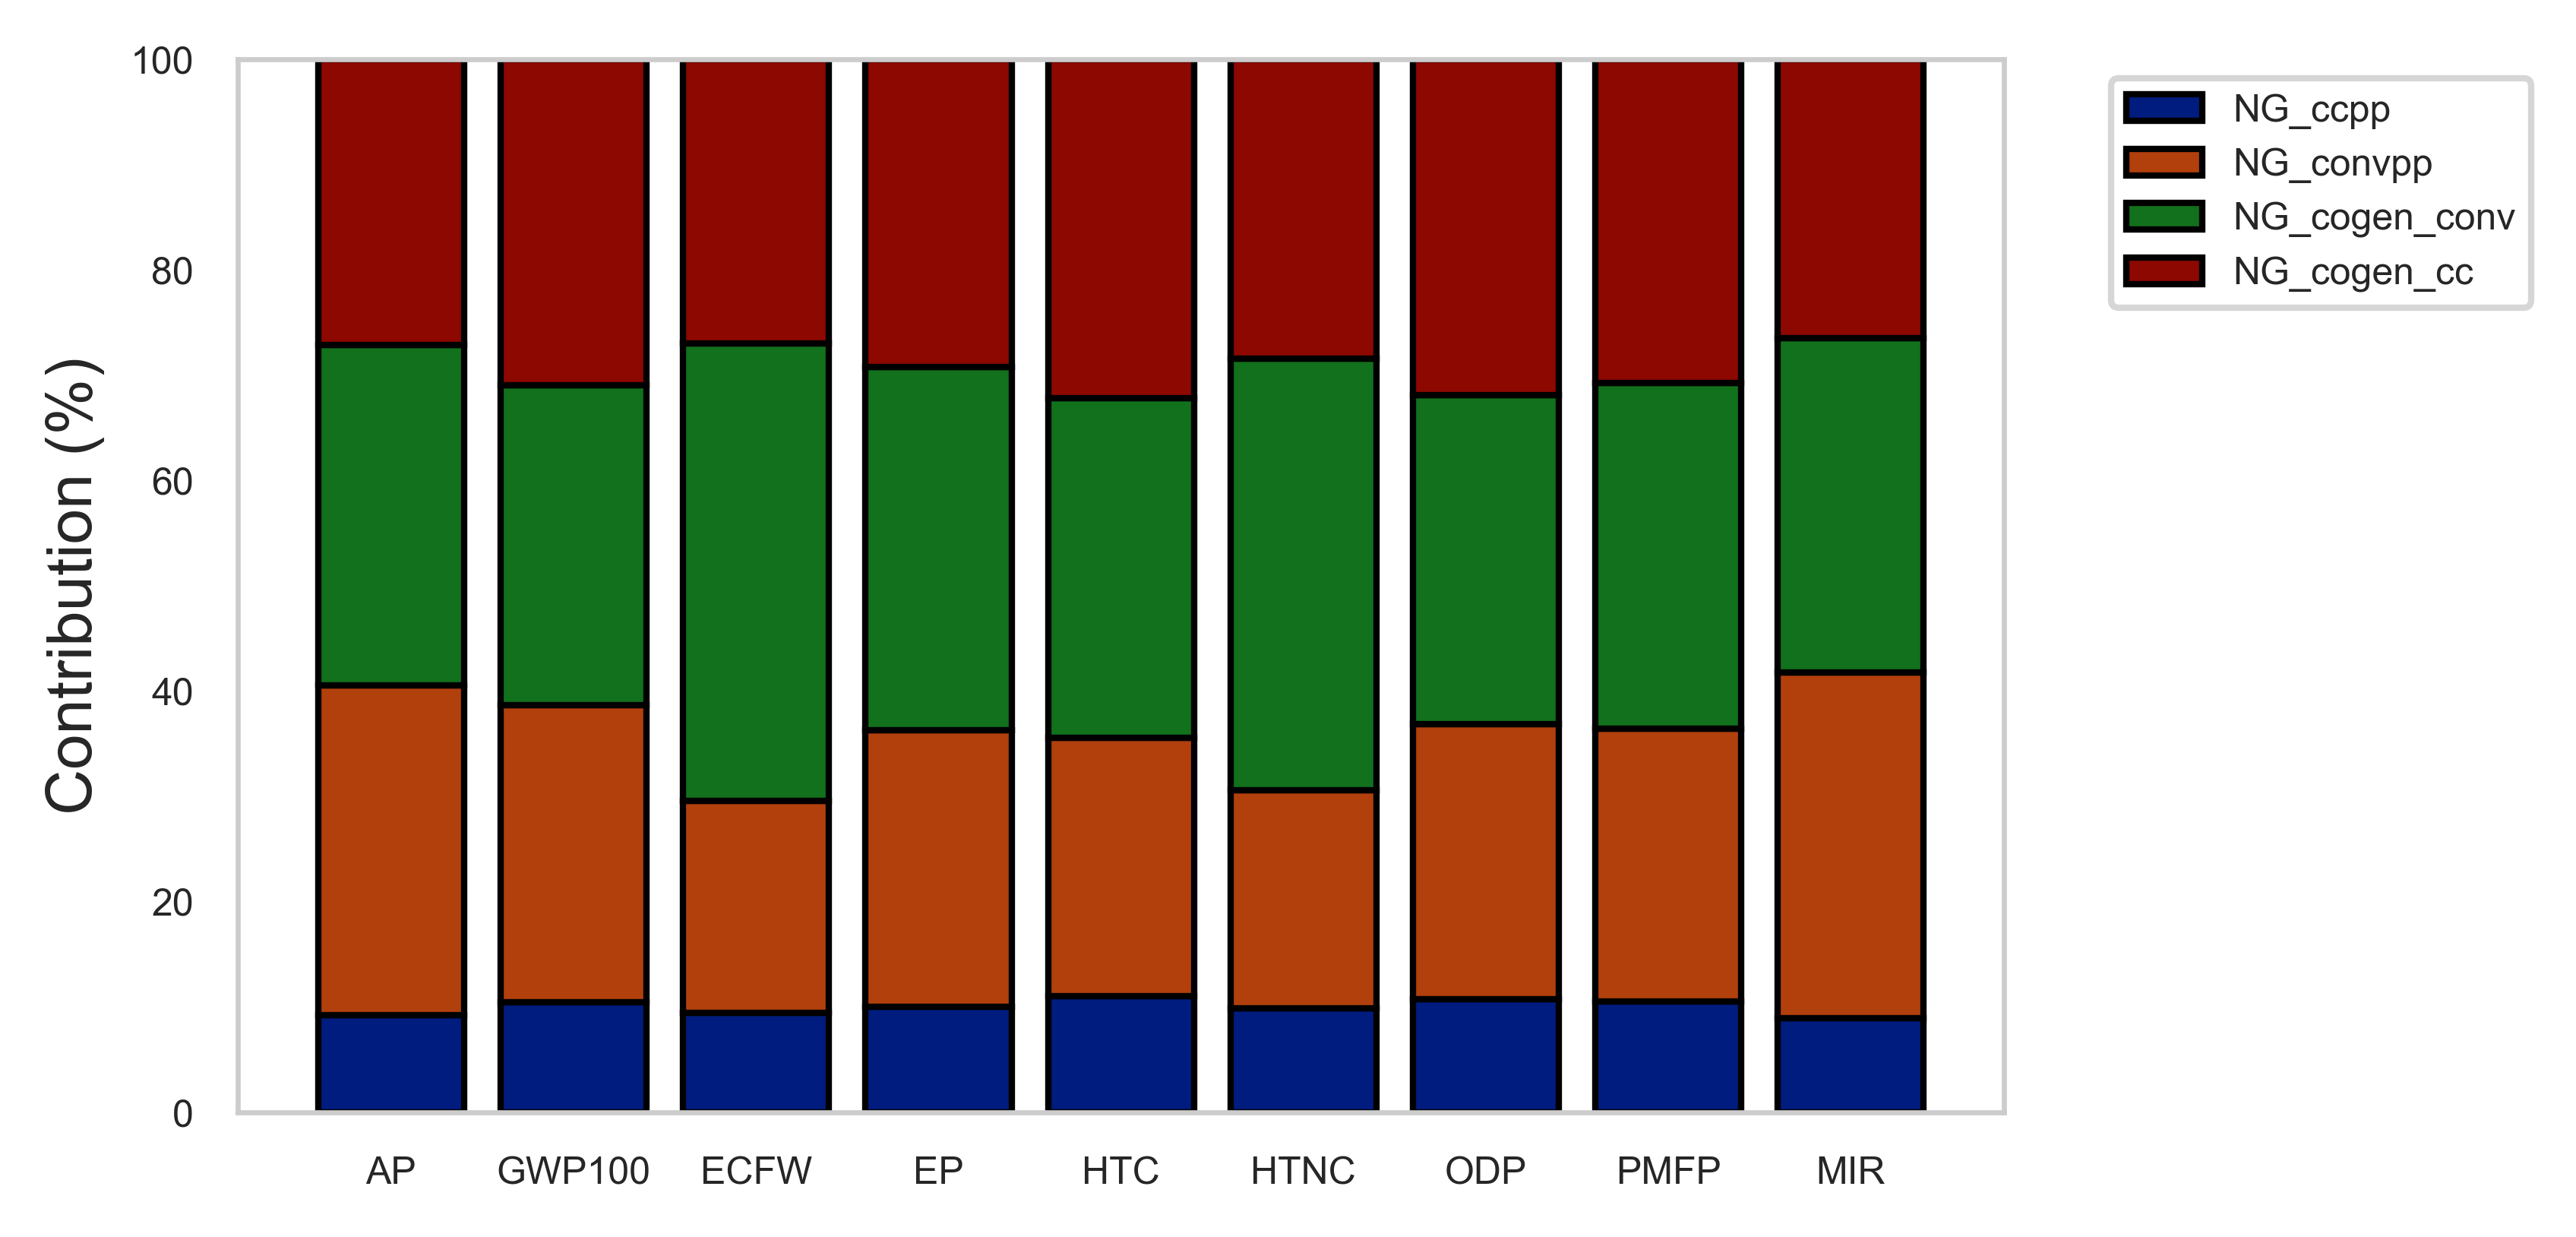

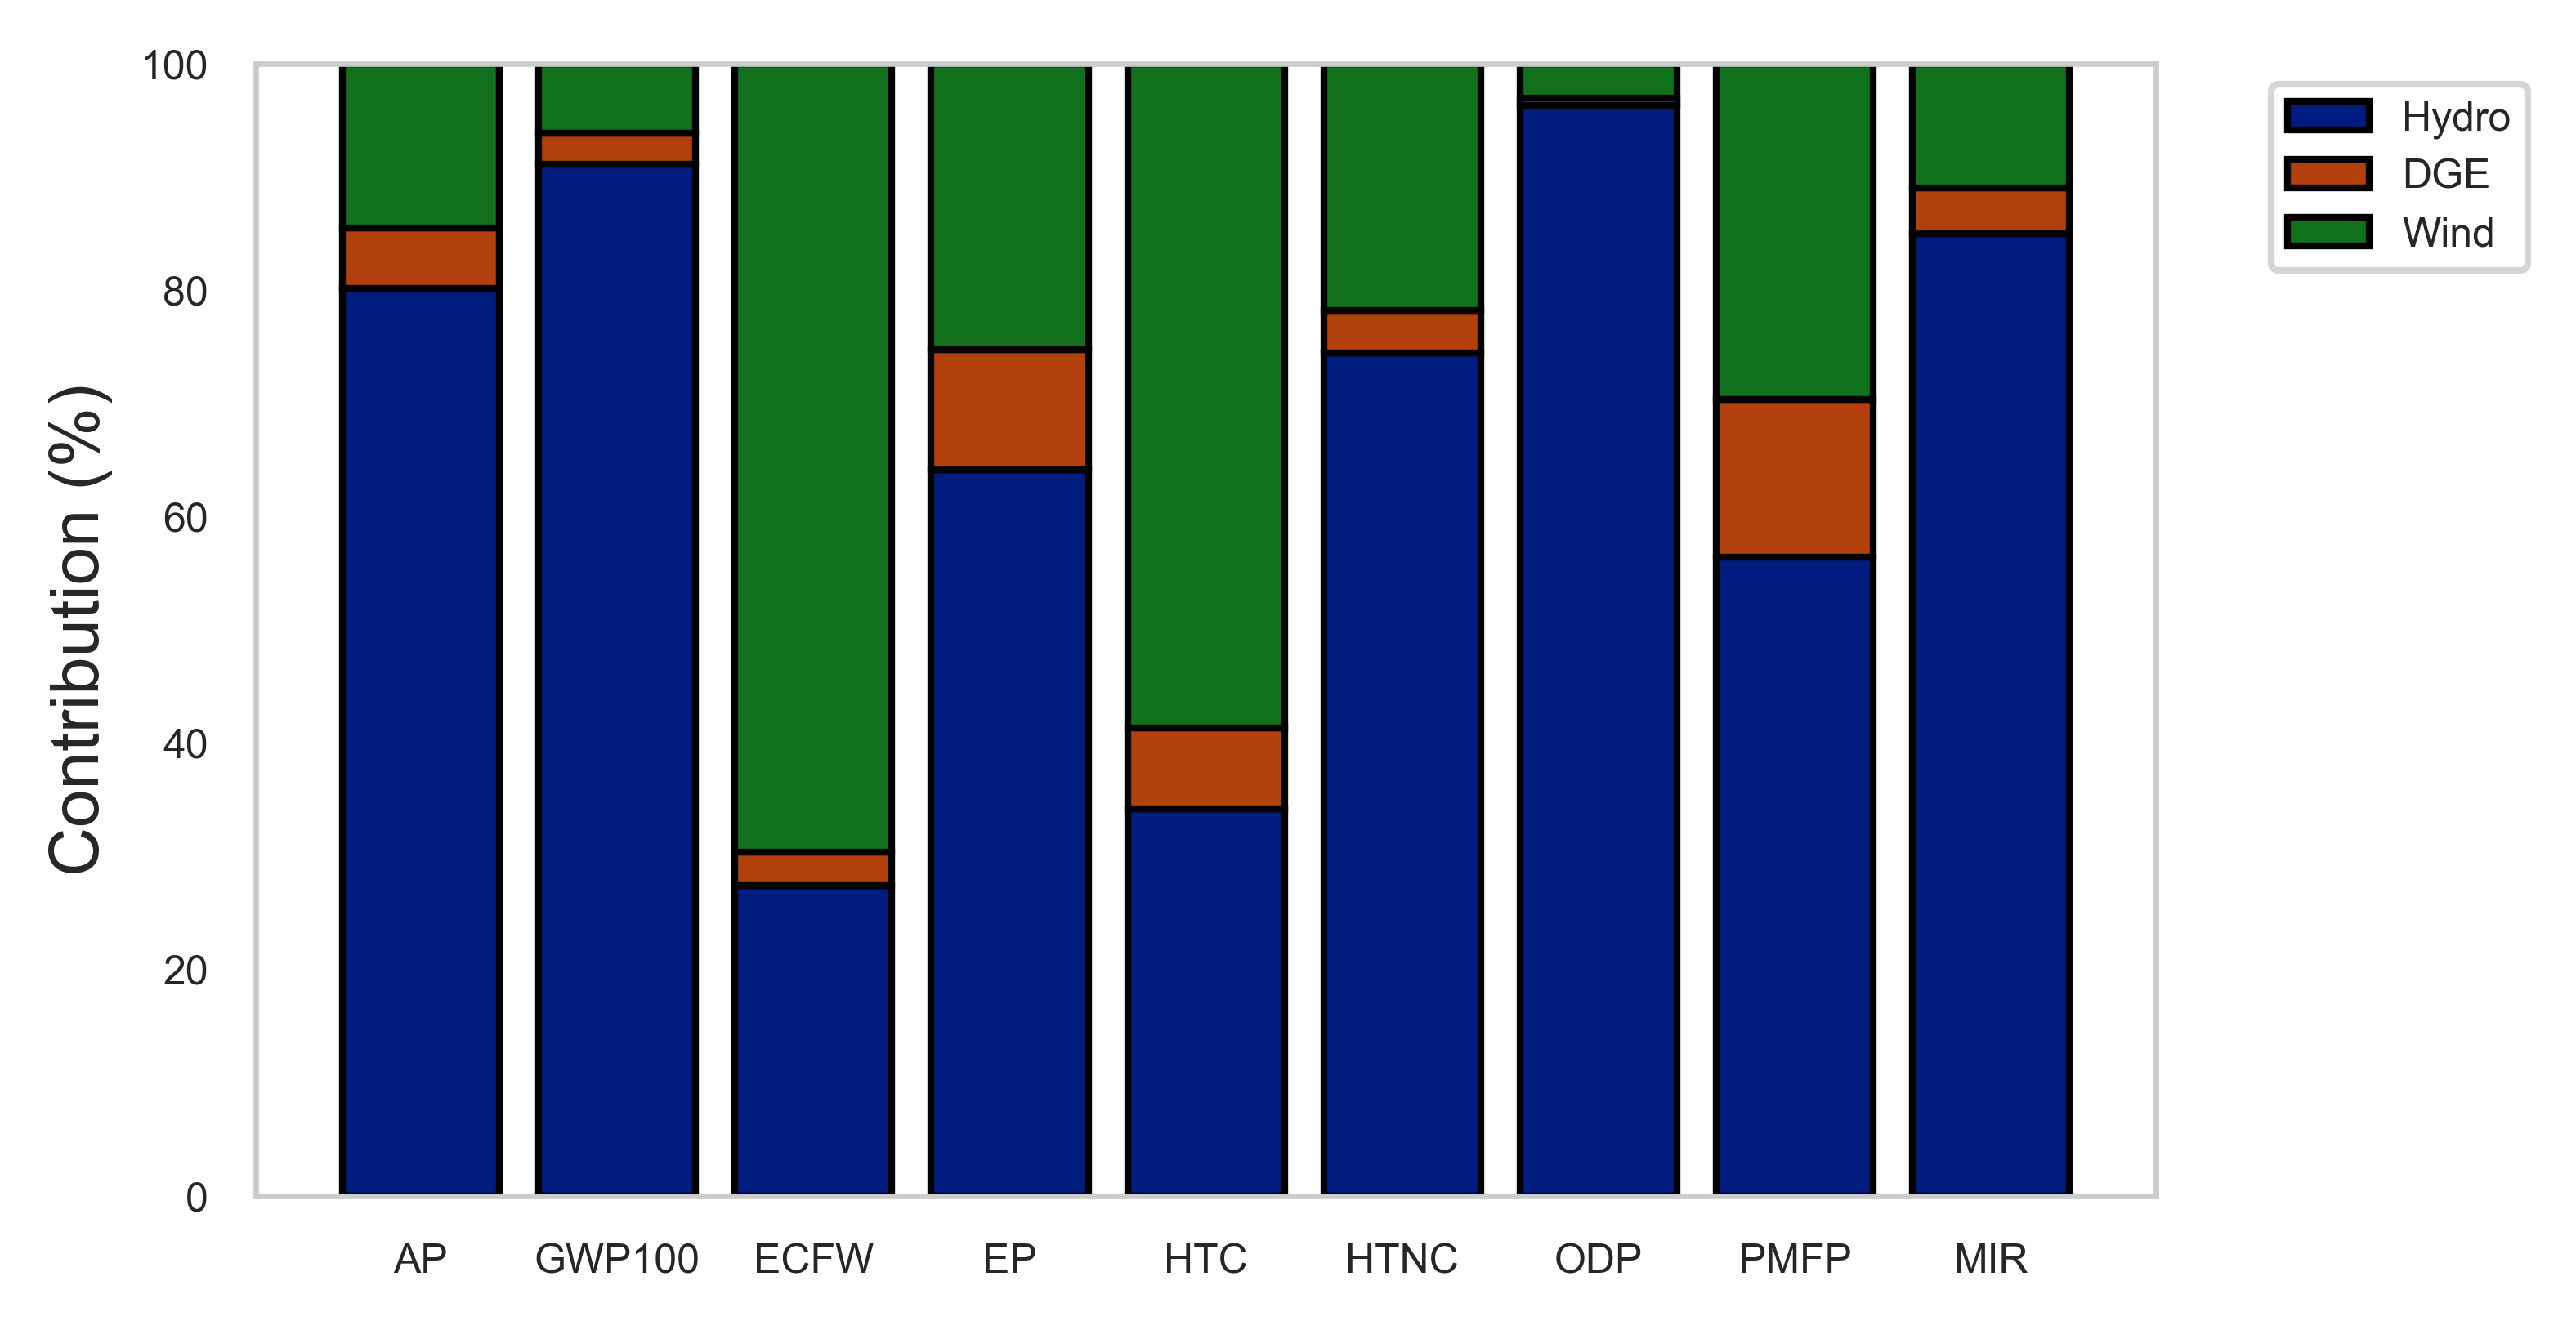

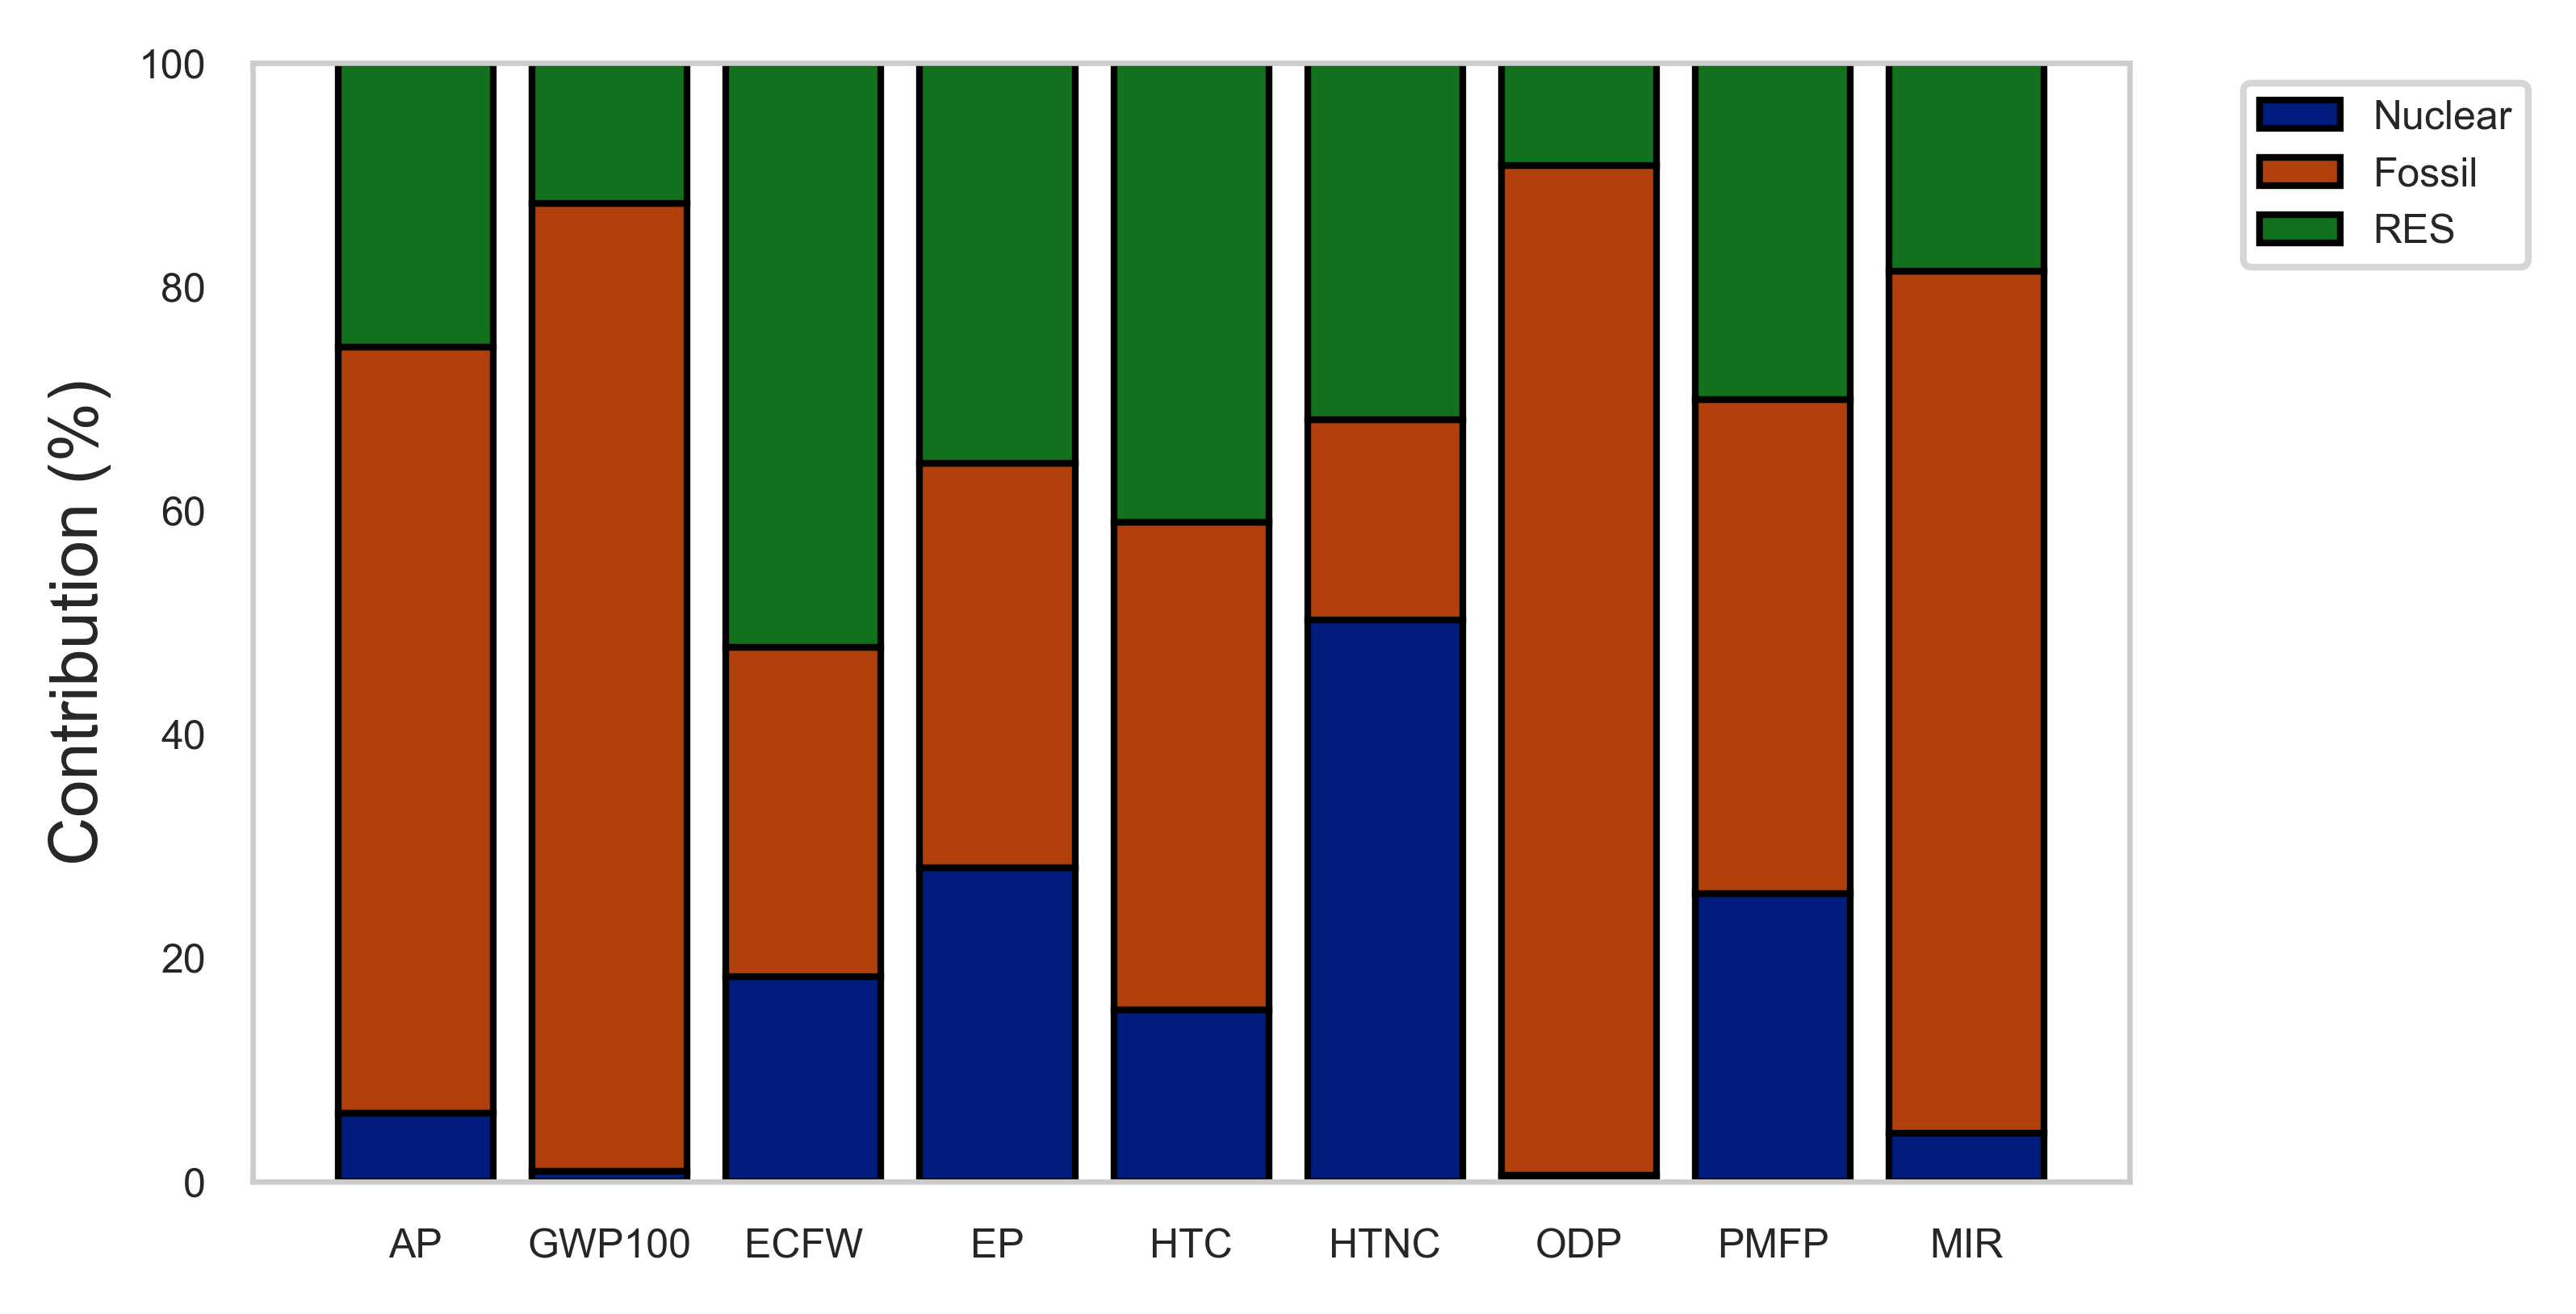

In [55]:
temp_list = list(dict_with_contribution_dfs.keys())
temp_list_2 = [s.replace(" ", "_") for s in temp_list]
for path, key in zip(temp_list_2, temp_list):
    figure_file_path = os.path.join(target_dir, f"{path}.png")
    plot_stacked_percentage_barchart_seaborn(dict_with_contribution_dfs[key][['AP', 'GWP100', 'ECFW', 'EP', 'HTC', 'HTNC', 'ODP', 'PMFP', 'MIR']], figure_file_path, verbose='False', figsize = (5,3), dpi = 600, tab = 'dark')

The results go to a depth of 2 after the main-process (sub-process and sub-sub-process). The brightway functions can be used to make a contribution analysis
for each sub-sub-process. The mpLCAer class includes these functions for bw2, taken from the github bw tutorials. Below how to use them through the mpLCAer class
given the ecoinvent key of the sub-sub-process

In [56]:
contribution_analysis_of_sub_sub_process_processes = my_lca.contribution_analysis_in_technosphere(['baacfa40ab20a187d037b569b8a7fca2_copy1'], methods_gp)

In [57]:
contribution_analysis_of_sub_sub_process_emissions = my_lca.contribution_analysis_in_biosphere(['baacfa40ab20a187d037b569b8a7fca2_copy1'], methods_gp)

# The main process as a sub-process

Above the impact of electricity production is assessed. Now imagine that we want to use this process as a sub-process in another main process (e.g., chemical production). Let's do this below.

### Example:

We have a process that uses 30 kWh of electricity, 13 kg of butanol, produces 2 kg of wastewater (to be treated), and produces 11 kg of a product X. Below we show the modelling of this process to calculate its impact per kg of product X produced.


Model the previous main process separately in its own dictionary and list

In [58]:
key_previously_main_process = {
'Electricity production': ''
}
exchange_list_previously_main_process = [
30/11
]

Model the other sub-processes (lets put everthing in one)

In [59]:
keys_other = {
'butanol consumption' :  'bw_key_pointing_to_relevant_process',
'Wastewater' :  'bw_key_pointing_to_relevant_process',
}
exchange_list_other =[
13/11,
-2/11,
]

Model the new main process in a dictionary and list only including the bw-based sub-processes (we will include the previous (externally calculated sub-process) later).

In [60]:
keys_total_new_main_process = {
'Butanol and wastewater' :  '',
}
total_exchanges_new_main_process = [
1.
]

Put in the lists only the other (ecoinvent-based) sub-processes, and perfrom same steps up to the unit impact calculation

In [61]:
key_list_new_main_process = [keys_other]

exchanges_list_new_main_process = [exchange_list_other]

In [62]:
mapping_new_main_process = create_mapping(keys_total_new_main_process, key_list_new_main_process)

In [63]:
unique_activities_new_main_process = create_list_with_unique_activities(key_list_new_main_process)

In [64]:
mapping_exch_new_main_process = create_mapping(keys_total_new_main_process, exchanges_list_new_main_process)

In [65]:
my_lca_new_main_process = mpLCAer(4, methods_gp, brightway_configuration_dictionary)

In [66]:
my_lca_new_main_process.import_isolated_environment()

In [67]:
my_lca_new_main_process.lca_calculations(mapping_new_main_process)

We have now calculated the unit_impacts for the other sub-processes. Here we will make some appends to the created lists/dataframes/dictionaries to include the previously calculated process. The same steps can be repeated to include non-bw based processes in the lcpy analysis (e.g., processes the impact/inventory of which are precalculated from another software). We do:

1) First, we append the unit_impacts we calculated in the previous modelling
2) Second, we append the mapping dictionary:
3) Third, we append the mapping_exchanges_dictionary:
4) Forth, we append the key_list_production_new_main_process list that holds the mapping dicitonaries for each sub-process
5) Fifth, we append the exchanges_list_production_new_main_process list that holds the exchanges amounts in lists for each each sub-process. We do not need to do that in principle, since we have already appended the required in the mapping_exch_new_main_process dictionary, but we do it for consistency and for better inspection
6) Sixth, we append the dictionaries of the new main process

In [68]:
my_lca_new_main_process.unit_impacts['Electricity production'] = mp_results_handler.total_impact_arrays['Electricity production'].reshape(1, len(impact_categories_names))

In [69]:
mapping_new_main_process['Electricity production'] = ['']

In [70]:
mapping_exch_new_main_process['Electricity production'] = [1.] # in case of multiple scenarios and time_steps the 1. should be an array

In [71]:
key_list_new_main_process.append({'Electricity production': ''})

In [72]:
exchanges_list_new_main_process.append([1.])

In [73]:
keys_total_new_main_process['Electricity production'] = ['']
total_exchanges_new_main_process.append(1.)

Once these appends are done, the subsequent modelling remains the same

In [74]:
sp_exchange_new_main_process = ExchangeHolder(methods_gp)
sp_impact_new_main_process = ImpactCalculator()

In [75]:
sp_exchange_new_main_process.create_exchange_arrays(mapping_exch_new_main_process)

In [76]:
sp_impact_new_main_process.impact_calculation_simple(my_lca_new_main_process.unit_impacts, sp_exchange_new_main_process.exchanges_dict)

In [77]:
sp_handler_new_main_process = ImpactHandler(impact_categories_names)

In [78]:
names_dictionary_new_main_process = create_name_dictionaries(mapping_new_main_process, key_list_new_main_process)

In [79]:
sp_handler_new_main_process.create_dataframes(sp_impact_new_main_process.simple_impacts, names_dictionary_new_main_process)

In [80]:
total_handler_new_main_process = ImpactHandler(impact_categories_names)

In [81]:
list_with_names_of_new_main_process = ['New main process']

In [82]:
total_handler_new_main_process.calculate_total_unit_impact(sp_handler_new_main_process.total_impact_arrays, list_with_names_of_new_main_process[0])

In [83]:
total_exchanger_new_main_process = ExchangeHolder(methods_gp)

In [84]:
total_impact_calculator_new_main_process = ImpactCalculator()

In [85]:
mapping_exch_total_new_main_process = {list_with_names_of_new_main_process[0]: total_exchanges_new_main_process}

In [86]:
names_dictionary_new_main_process_main = {list_with_names_of_new_main_process[0]: list(names_dictionary_new_main_process.keys()) }

In [87]:
mapping_exch_total_new_main_process

{'New main process': [1.0, 1.0]}

In [88]:
total_exchanger_new_main_process.create_exchange_arrays(mapping_exch_total_new_main_process)

In [89]:
total_impact_calculator_new_main_process.impact_calculation_simple(total_handler_new_main_process.total_unit_impact, total_exchanger_new_main_process.exchanges_dict)

In [90]:
total_handler_new_main_process.create_dataframes(total_impact_calculator_new_main_process.simple_impacts, names_dictionary_new_main_process_main)

In [91]:
df_list_new_main_process = list(sp_handler_new_main_process.df_contributions.values())
df_list_new_main_process.append(total_handler_new_main_process.df_contributions['New main process'])

In [92]:
sheet_names_new_main_process = list(keys_total_new_main_process.keys()) + ['Total']

In [93]:
dict_with_dfs_contr_new_main_process = create_dataframe_dict(df_list_new_main_process, sheet_names_new_main_process)

In [94]:
df_list_total_new_main_process = list(sp_handler_new_main_process.df_impacts.values())

In [95]:
df_list_total_new_main_process.append(total_handler_new_main_process.df_impacts['New main process'])

In [96]:
dict_with_dfs_total_new_main_process = create_dataframe_dict(df_list_total_new_main_process, sheet_names_new_main_process)

In [97]:
excel_file_path_contr_new_main_process = os.path.join(target_dir, 'Contributions_new_main_process.xlsx')

In [98]:
save_dataframes_to_excel(dict_with_dfs_contr_new_main_process, excel_file_path_contr_new_main_process)

Excel file 'C:\Users\sgkousis\Desktop\Example_results\Simple_LCA\Contributions_new_main_process.xlsx' saved successfully.


In [99]:
excel_file_path_total_new_main_process = os.path.join(target_dir, 'Totals_new_main_process.xlsx')

In [100]:
save_dataframes_to_excel(dict_with_dfs_total_new_main_process, excel_file_path_total_new_main_process)

Excel file 'C:\Users\sgkousis\Desktop\Example_results\Simple_LCA\Totals_new_main_process.xlsx' saved successfully.


In [101]:
sp_handler_new_main_process.contribution_to_total_impact_per_sub_sub_processes(dict_with_dfs_total_new_main_process, dict_with_dfs_contr_new_main_process, unique_activities_new_main_process, name= 'new main process', target_dir = target_dir)

In [102]:
# figure_file_path = os.path.join(target_dir, f"sub_process_contributions_subplot_new_main_process.png")
# plot_stacked_percentage_bar_grid(sp_handler_new_main_process.contribution_per_sub_sub_process, ['AP', 'GWP100', 'ECFW', 'EP', 'HTC', 'HTNC', 'ODP', 'PMFP', 'MIR'], figure_file_path, figsize=(15, 12), dpi=600, top_x=5, xlabel="Activities", ylabel="Contribution (%)")

In [103]:
# temp_list = list(dict_with_dfs_contr_new_main_process.keys())
#
# for cat in ['AP', 'GWP100', 'ECFW', 'EP', 'HTC', 'HTNC', 'ODP', 'PMFP', 'MIR']:
#     figure_file_path = os.path.join(target_dir, f"sub_process_contributions{cat}_new_main_process.png")
#     plot_stacked_percentage_bar_sub_processes(sp_handler_new_main_process.contribution_per_sub_sub_process, cat, figure_file_path, verbose = 'False')

In [104]:
# temp_list = list(dict_with_dfs_contr_new_main_process.keys())
# temp_list_2 = [s.replace(" ", "_") for s in temp_list]
# for path, key in zip(temp_list_2, temp_list):
#     figure_file_path = os.path.join(target_dir, f"{path}_new_main_process.png")
#     plot_stacked_percentage_barchart_seaborn(dict_with_dfs_contr_new_main_process[key][['AP', 'GWP100', 'ECFW', 'EP', 'HTC', 'HTNC', 'ODP', 'PMFP', 'MIR']], figure_file_path, verbose='False', figsize = (5,3), dpi = 600, tab = 'dark')